# Preparación de datos - G6

In [402]:
# Liberias
import pandas as pd
import numpy as np
from unidecode import unidecode
from datetime import date
import rasterio
pd.set_option('display.max_columns', None)


#libs
## Librerías de visualización 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns


from thefuzz import process, fuzz

## 1. Base de datos principal

- Casos confirmados de Dengue y Dengue grave mensual 2007 a 2024 agregado por municipio de residencia, obtenida del SISPRO del ministerio de salud.
- Codigo divipola y coordenadas obtenidas de datos del DANE
https://www.datos.gov.co/Mapas-Nacionales/DIVIPOLA-C-digos-municipios-geolocalizados/vafm-j2df/about_data
- Datos climaticos mesnuales de temperatura y precipitación obtenidos de archivos historicos de WorldClim
https://www.worldclim.org/data/monthlywth.html


En esta primera sección se realiza la lectura y preparación inicial de las fuentes de datos, a continuación se lee la base de datos extraida del Sistema de Información de Salud y Protección social (SISPRO), estos datos son de consulta pública con usuario y contienen el consolidado de casos de Dengue y Dengue Grave para el aplicativo propuesto

In [403]:
####################### PARAMETRO PINCIPAL #######################
#* Se escoge que tipo de casos se va a usar para el análisis, si casos confirmados por lugar 
#* de residencia o casos confirmados por lugar de ocurrencia
#! Cambia a 'ocur' si se va a usar casos confirmados en lugar de ocurrencias
#! 'res' para casos confirmado por lugar de residencia
hoja_start = 'ocur'
#* parametro lag_size para crear variables de lag
lag_size = 8

In [404]:
import pandas as pd
import numpy as np
import rasterio
from unidecode import unidecode
import calendar
from pathlib import Path

def normalize_str(s):
    """Utility to clean and normalize strings."""
    if not isinstance(s, str):
        return s
    return unidecode(str(s).split('-')[-1].strip().lower())

def load_db(f_path, sheet_name):
    """
    Carga y preprocesa los datos de dengue desde un archivo Excel.
    """
    # Usar converter para evitar problemas de tipos en columnas conocidas
    df = pd.read_excel(f_path, sheet_name=sheet_name)
    print(f"Original shape: {df.shape}")
    print(f"Original columns: {df.columns.tolist()}")
    print(f'Original info:\n{df.info()}')
    df.fillna(0, inplace=True)  # Rellenar NaN con 0 para evitar problemas en el melt
    # 1. Clean column names
    df.columns = [normalize_str(c) for c in df.columns]
    df.rename(columns={'ano epidemiologico': 'year'}, inplace=True)

    # 2. Filter and Normalize strings
    df = df[~df['municipio'].str.contains('Sin Informacion', na=False)]
    df = df[df['pais'] != 'no definido']
    
    cols_to_fix = ['pais', 'departamento', 'municipio']
    for col in cols_to_fix:
        df[col] = df[col].apply(normalize_str)

    # 3. Reshape (Melt)
    df = df.melt(
        id_vars=['pais', 'departamento', 'municipio', 'year'],
        var_name='mes',
        value_name='casosconfirmados'
    )

    # 4. Map Months using standard library
    # Creates a map: {'Enero': 1, ...} assuming names are in Spanish as in the snippet
    month_names = ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 
                   'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']
    mes_mapping = {name: i+1 for i, name in enumerate(month_names)}
    
    df['mes'] = df['mes'].map(mes_mapping)
    
    return df

def fill_location_timeseries(df):
    """
    Completa la serie temporal para cada combinación de Departamento y Municipio,
    asegurando que el rango de fechas sea específico para el inicio y fin 
    de cada ubicación (departamento-municipio).
    """
    # 1. Asegurar que exista la columna 'date'
    if 'date' not in df.columns:
        df['date'] = pd.to_datetime(pd.DataFrame({
            'year': df['year'],
            'month': df['mes'],
            'day': 1
        }))
    
    # 2. Definir las columnas que identifican la ubicación
    location_cols = ['departamento', 'municipio']
    
    # 3. Agrupar por ubicación y aplicar resample
    # El método resample('MS') (Month Start) dentro de un groupby
    # crea automáticamente el rango desde la fecha mínima a la máxima de CADA grupo.
    df_complete = (
        df.set_index('date')
        .groupby(location_cols)
        .resample('MS')
        .asfreq()  # Inserta filas con NaN para las fechas faltantes
        .drop(columns=location_cols, errors='ignore') # Eliminamos las columnas para que no se dupliquen al resetear index
        .reset_index()
    )
    
    # 4. Restaurar los valores de Year y Month para las nuevas filas
    df_complete['year'] = df_complete['date'].dt.year
    df_complete['mes'] = df_complete['date'].dt.month
    
    # Nota: 'casosconfirmados' y cualquier otra variable 
    # quedarán como NaN automáticamente en los huecos internos.
    
    return df_complete.sort_values(location_cols + ['date']).reset_index(drop=True)

def add_worldclim(df: pd.DataFrame,
                  path_divipola: str = 'data/Listados_DIVIPOLA.xlsx',
                  sheet_divipola: str = 'Municipios',
                  elevation_files: dict = None,
                  climate_folders: dict = None,
                  lags: int = 8):  # <-- ADDED PARAMETER
    
    if elevation_files is None:
        elevation_files = {'elevacion': Path('data/worldclim/wc2.1_2.5m_elev/wc2.1_2.5m_elev.tif')}
    if climate_folders is None:
        climate_folders = {
            'tmin': [Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmin_2000-2009'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmin_2010-2019'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmin_2020-2024')],
            'tmax': [Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmax_2000-2009'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmax_2010-2019'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_tmax_2020-2024')],
            'prec': [Path('data/worldclim/wc2.1_cruts4.09_2.5m_prec_2000-2009'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_prec_2010-2019'),
                     Path('data/worldclim/wc2.1_cruts4.09_2.5m_prec_2020-2024')]
        }

    # 1. Load and Clean DIVIPOLA
    divipola = pd.read_excel(path_divipola, sheet_name=sheet_divipola, skiprows=10, skipfooter=10)
    divipola.columns = ['cod_dept', 'departamento', 'cod_muni', 'municipio', 'tipo', 'longitud', 'latitud', 'nota']
    divipola = divipola[['departamento', 'municipio', 'cod_muni', 'tipo', 'longitud', 'latitud']]
    
    for col in ['departamento', 'municipio']:
        divipola[col] = divipola[col].apply(normalize_str) # Assuming normalize_str is defined elsewhere

    # 2. Municipality Name Harmonization
    renamer = {
        'putumayo': {'leguizamo': 'puerto leguizamo'},
        'cauca': {'sotara': 'sotara paispamba', 'piendamo': 'piendamo - tunia', 'lopez': 'lopez de micay'},
        'valle del cauca': {'cali': 'santiago de cali'},
    }
    
    for dept, muni_map in renamer.items():
        mask = df['departamento'] == dept
        df.loc[mask, 'municipio'] = df.loc[mask, 'municipio'].replace(muni_map)

    # 3. Filter only valid locations
    df['loc_key'] = df['departamento'] + "_" + df['municipio']
    divipola['loc_key'] = divipola['departamento'] + "_" + divipola['municipio']
    
    df = df[df['loc_key'].isin(divipola['loc_key'])]
    df = df.merge(divipola.drop(columns=['departamento', 'municipio']), on='loc_key', how='left')

    # 4. Extract Elevation (Rasterio)
    unique_locs = df[['loc_key', 'longitud', 'latitud']].drop_duplicates()
    coords = list(zip(unique_locs['longitud'], unique_locs['latitud']))
    
    for var, path in elevation_files.items():
        with rasterio.open(path) as src:
            unique_locs[var] = [val[0] for val in src.sample(coords)]
            
    df = df.merge(unique_locs[['loc_key', 'elevacion']], on='loc_key', how='left')

    # =========================================================================
    # 5. Extract Climate Data (Optimized for Temporal Lags)
    # =========================================================================
    
    # Ensure year and month are numeric for calculations
    df['year'] = df['year'].astype(int)
    df['mes'] = df['mes'].astype(int)

    # Determine the absolute time range needed, including the past buffer for lags
    start_date = pd.to_datetime(f"{df['year'].min()}-{df['mes'].min():02d}-01")
    start_date_lagged = start_date - pd.DateOffset(months=lags)
    end_date = pd.to_datetime(f"{df['year'].max()}-{df['mes'].max():02d}-01")

    # Generate a continuous timeline of all months required
    all_dates = pd.date_range(start=start_date_lagged, end=end_date, freq='MS')
    
    climate_data_blocks = []
    
    for dt in all_dates:
        y = dt.year
        m = dt.month
        m_str = f"{m:02d}"
        idx = 0 if y <= 2009 else (1 if y <= 2019 else 2)
        
        # Pre-allocate dictionary for this specific year/month
        month_data = {
            'loc_key': unique_locs['loc_key'].tolist(),
            'year': [y] * len(unique_locs),
            'mes': [m] * len(unique_locs)
        }
        
        for var, folders in climate_folders.items():
            folder = folders[idx]
            file_name = f"{folder.name.rsplit('_', 1)[0]}_{y}-{m_str}.tif"
            file_path = folder / file_name
            
            if file_path.exists():
                with rasterio.open(file_path) as src:
                    # Sample all locations at once for this file
                    month_data[var] = [val[0] for val in src.sample(coords)]
            else:
                # Handle missing files gracefully
                month_data[var] = [None] * len(unique_locs)
                
        climate_data_blocks.append(pd.DataFrame(month_data))

    # Combine all months into a single continuous DataFrame
    climate_df = pd.concat(climate_data_blocks, ignore_index=True)

    # =========================================================================
    # 6. Calculate Lags and Final Merge
    # =========================================================================
    
    # Sort strictly by location and time to ensure shift() works correctly
    climate_df = climate_df.sort_values(['loc_key', 'year', 'mes'])
    
    # Calculate lags for each variable
    vars_to_lag = list(climate_folders.keys())
    for lag in range(1, lags + 1):
        for var in vars_to_lag:
            climate_df[f'{var}_lag{lag}'] = climate_df.groupby('loc_key')[var].shift(lag)

    # Merge the comprehensive climate dataframe back onto the main dataframe
    # Because we fetched 2006 data, the 2007 rows will merge with their lags intact!
    final_df = df.merge(climate_df, on=['loc_key', 'year', 'mes'], how='left')
    
    # Standardize column names
    rename_dict = {'prec': 'Precipitacion', 'tmax': 'TempMax', 'tmin': 'TempMin'}
    for lag in range(1, lags + 1):
        rename_dict[f'prec_lag{lag}'] = f'Precipitacion_lag{lag}'
        rename_dict[f'tmax_lag{lag}'] = f'TempMax_lag{lag}'
        rename_dict[f'tmin_lag{lag}'] = f'TempMin_lag{lag}'
        
    final_df.rename(columns=rename_dict, inplace=True)
    
    # Cleanup
    final_df.drop(columns=['loc_key'], inplace=True)
    
    return final_df

En la fase inicial, se identifica que los registros de SIVIGILA pueden presentar discontinuidades temporales o falta de reportes en meses específicos para ciertos municipios. Para resolver esto, la función load_db transforma los datos de un formato ancho (meses como columnas) a uno "largo" o tidy data, eliminando registros sin información. Posteriormente, mediante la función fill_location_timeseries, se genera una serie de tiempo continua para cada locación. Este proceso asegura que cada combinación de Departamento y Municipio cuente con una fila por cada mes dentro de su rango histórico, estandarizando las fechas al primer día de cada mes para facilitar el análisis posterior.

Para la georreferenciación, se integra la base de datos de la codificación DIVIPOLA del DANE. Esta fuente provee las coordenadas geográficas (latitud y longitud), el código oficial del municipio y su clasificación (municipio, isla o área no municipalizada). Estas variables son fundamentales para el reconocimiento espacial y la posterior vinculación de datos satelitales.

Sin embargo, para lograr una unión (merge) exitosa, es imperativo normalizar los nombres de las locaciones. Dado que los sistemas SIVIGILA y DANE suelen tener discrepancias ortográficas, se aplica un proceso de limpieza que incluye la conversión a minúsculas, la eliminación de caracteres especiales y acentos (mediante unidecode), y el uso de un diccionario de homologación (renamer). Este diccionario corrige nombres específicos (por ejemplo, transformando "Cali" en "Santiago de Cali" o "Leguizamo" en "Puerto Leguizamo") para garantizar la integridad referencial entre ambas fuentes.

Finalmente, se procede al enriquecimiento ambiental mediante el procesamiento de archivos ráster con la librería rasterio. En primer lugar, se extrae la elevación exacta de cada municipio basándose en sus coordenadas. Luego, se integran las variables climáticas de WorldClim (precipitación, temperatura máxima y mínima). Este paso es dinámico y preciso: el sistema identifica el archivo histórico correspondiente a cada registro según su año y mes, extrayendo los valores climáticos específicos para ese punto geográfico. El resultado final es una base de datos robusta, con continuidad temporal y variables biofísicas listas para modelos de predicción.

In [405]:

df = load_db('data/Base_deng.xlsx', sheet_name=hoja_start)

df = fill_location_timeseries(df)

df = add_worldclim(df)

df.head()

df.to_csv(f'data/dengue_data_v2_{hoja_start}.csv', index=False, sep='|')


Original shape: (14684, 16)
Original columns: ['País', 'Departamento', 'Municipio', 'Año Epidemiologico', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
<class 'pandas.DataFrame'>
RangeIndex: 14684 entries, 0 to 14683
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   País                14684 non-null  str    
 1   Departamento        14684 non-null  str    
 2   Municipio           14684 non-null  str    
 3   Año Epidemiologico  14684 non-null  int64  
 4   Enero               8507 non-null   float64
 5   Febrero             7816 non-null   float64
 6   Marzo               7786 non-null   float64
 7   Abril               7895 non-null   float64
 8   Mayo                8097 non-null   float64
 9   Junio               8251 non-null   float64
 10  Julio               8444 non-null   float64
 11  Agosto              8083 non-

In [406]:
df = pd.read_csv(f'data/dengue_data_v2_{hoja_start}.csv', sep='|')
df

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,TempMin,TempMax,Precipitacion,TempMin_lag1,TempMax_lag1,Precipitacion_lag1,TempMin_lag2,TempMax_lag2,Precipitacion_lag2,TempMin_lag3,TempMax_lag3,Precipitacion_lag3,TempMin_lag4,TempMax_lag4,Precipitacion_lag4,TempMin_lag5,TempMax_lag5,Precipitacion_lag5,TempMin_lag6,TempMax_lag6,Precipitacion_lag6,TempMin_lag7,TempMax_lag7,Precipitacion_lag7,TempMin_lag8,TempMax_lag8,Precipitacion_lag8
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,31,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,22.0,30.0,349.8,21.0,30.0,517.3
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,23,32,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,22.0,30.0,349.8
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,30,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,30,538.6,22.0,30.0,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,29,392.1,22.0,30.0,538.6,22.0,30.0,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202171,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,22,31,255.6,23.0,30.0,325.7,22.0,29.0,431.9,24.0,31.0,340.8,23.0,33.0,231.1,23.0,35.0,70.7,24.0,36.0,31.3,22.0,35.0,15.9,23.0,32.0,37.8
202172,vichada,santa rosalia,2024-09-01,colombia,2024,9,3.0,99624,Municipio,-70.859499,5.136393,116,23,32,211.5,22.0,31.0,255.6,23.0,30.0,325.7,22.0,29.0,431.9,24.0,31.0,340.8,23.0,33.0,231.1,23.0,35.0,70.7,24.0,36.0,31.3,22.0,35.0,15.9
202173,vichada,santa rosalia,2024-10-01,colombia,2024,10,2.0,99624,Municipio,-70.859499,5.136393,116,23,32,238.2,23.0,32.0,211.5,22.0,31.0,255.6,23.0,30.0,325.7,22.0,29.0,431.9,24.0,31.0,340.8,23.0,33.0,231.1,23.0,35.0,70.7,24.0,36.0,31.3
202174,vichada,santa rosalia,2024-11-01,colombia,2024,11,0.0,99624,Municipio,-70.859499,5.136393,116,23,32,149.6,23.0,32.0,238.2,23.0,32.0,211.5,22.0,31.0,255.6,23.0,30.0,325.7,22.0,29.0,431.9,24.0,31.0,340.8,23.0,33.0,231.1,23.0,35.0,70.7


### 1.1. Datos de fenomeno del niño y la niña (añadidos a base principal)

Se agregan datos del fenomeno del niño y de la niña con marcación categorica, este tipo de variable se debe agregar con rezagos temporales para la base definitiva, ya que la presencia continua de temeperaturas aumentadas o disminuidas son precisamente las que denotan que el fenomeno se acentue y se haga mención de su impacto a nivel nacional.

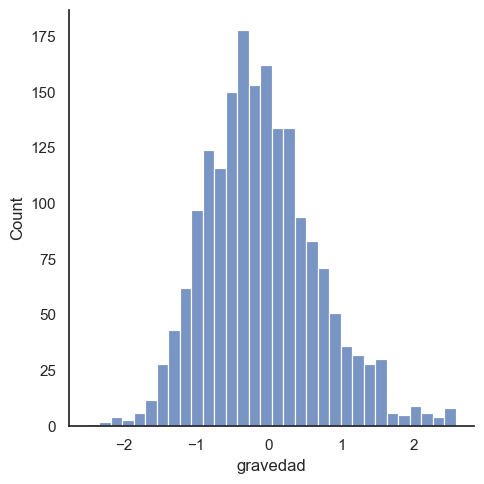

In [407]:
df_nino = pd.read_csv('data/nino34.long.anom.csv')
#* cambio en nobmres de columnas
df_nino.columns = ['date', 'gravedad']
#* se reemplazo el -99.99 por pd.na ya que es el dato faltante
df_nino['fenomeno'] = df_nino['gravedad'].apply(lambda x: pd.na if x==-99.99 else x)
#* agregar marcacion de la gravedad, si es >=1.5 nino_sev, 1.5>x>=0.5 es nino_moderado
df_nino['fenomeno'] = df_nino['gravedad'].apply(lambda x: 'nino_sev' if x >= 1.5 else
                                                          'nino_mod' if 1.5>x>=0.5 else
                                                          'neutral' if 0.5 > x >-0.5 else
                                                          'nina_mod' if -1.5<x<=-0.5 else
                                                          'nina_sev')

sns.displot(df_nino, x="gravedad")
df_nino.drop(columns='gravedad', inplace=True)
#* crear lags de nino

def lag_features(df,target_cols, lags):
    for target in target_cols:
        for lag in lags:
            lag_col_name = f"{target}_lag{lag}"
            df[lag_col_name] = df[target].shift(lag)
    return df


df_nino = lag_features(df_nino,
                      target_cols=['fenomeno'],
                      lags=[1, 2, 3,4,5,6,7,8])


#* merge df and df_nino on date
df = df.merge(df_nino, on='date', how='left')

# df.to_csv(f'data/dengue_data_v2_{hoja_start}.csv', index=False, sep='|')

In [408]:
print(df.shape)
df.head()
#* create dictionary with number of rows per departamento-municipio
location_counts = df.groupby(['departamento', 'municipio']).size().to_dict()

(202176, 48)


### 1.2. Datos de variables ambientales y climaticas adicionales

In [409]:
vars_amb = pd.read_csv('data/climaticas_aedes_colombia.csv')

vars_amb.rename(columns={'ADM2_NAME': 'municipio',
                                'ADM1_NAME': 'departamento',
                                'month':'mes'}, inplace=True)

vars_amb = vars_amb[(vars_amb['year'] >= 2006) & vars_amb['year']<= 2024] #* filtrar por año para que coincida con el rango de df
vars_amb.head()
vars_amb.columns = [normalize_str(c) for c in vars_amb.columns]


cols_to_fix = ['departamento', 'municipio']
for col in cols_to_fix:
    vars_amb[col] = vars_amb[col].apply(normalize_str)
#* list of tuples wiht not valid dept, muni and must be dropped from vars_amb
invalid_locations = [('antioquia', 'necocli (is.)'),
                     ('boyaca','mongua'),
                     ('boyaca','sora'),
                     ('cauca', 'timbiqui (is.)'),
                     ('choco', 'el litoral del san juan (is.'), 
                     ('choco', 'litoral del san juan (is.'),
                     ('choco','jurado (is.)'),
                     ('cordoba', 'monY=itos'),
                     ('cordoba','san bernardo el viento (i'),
                     ('cundinamarca','susa'),
                     ('narino', 'el charco (is.)'),
                     ('narino', 'mosquera (is.)'),
                     ('norte de santander', 'cucuta'),
                     ('sucre', 'san onofre (is.)'),
                     ('valle del cauca', 'buenaventura (is.)'),
                     ('valle del cauca', 'buga') 
                     ]

for dept, muni in invalid_locations:
    vars_amb = vars_amb[~((vars_amb['departamento'] == dept) & (vars_amb['municipio'] == muni))]
#* set departamento bogota, d.c. for bogota municipio
vars_amb.loc[vars_amb['municipio'] == 'santafe de bogota d.c.', 'departamento'] = 'bogota, d.c.' #bogota, d.c.

#* NDVI (Normalized Difference Vegetation Index)
#* TempSuperficie (Land Surface Temperature - LST) NOT USED
#* TempAir NOT USED
#* precipitacion NOT USED
#* dew_point (humedad)
vars_amb.drop(columns=['lst', 'temp_air', 'precip'], inplace=True)

vars_amb['key'] = vars_amb['departamento'] + "_" + vars_amb['municipio']

df['key'] = df['departamento'] + "_" + df['municipio']

#* igualar dtpyes year mes de df a los de vars_amb
df['year'] = df['year'].astype(int)
df['mes'] = df['mes'].astype(int)
vars_amb['year'] = vars_amb['year'].astype(int)
vars_amb['mes'] = vars_amb['mes'].astype(int)

#* check for missing keys in vars_amb
missing_keys = list(set(vars_amb['key'])-set(df['key']))
# missing_keys

In [410]:
map = {}
for info in missing_keys:
    #* select dept
    depo = info.split('_')[0]
    muni = info.split('_')[1]
    #* subset depo munis from df
    subset = df.loc[(df['departamento'] == depo), 'municipio'].tolist()
    #* get closest match for muni in subset
    closest_match = process.extractOne(muni, subset, scorer=fuzz.token_sort_ratio)
    if closest_match and closest_match[1] >= 80:  # Threshold for a good match
        if depo not in map:
            map[depo] = {muni: closest_match[0]}
        else:
            map[depo][muni] = closest_match[0]
    else:
        if depo not in map:
            map[depo] = {muni: None}
        else:
            map[depo][muni] = None

# map

In [411]:
#* Valle del cauca
map['valle del cauca']['cali'] = 'santiago de cali'
map['valle del cauca']['buga'] = 'bugalagrande'
map['valle del cauca']['calima  (darien)'] = 'calima'
#* boyaca
map['boyaca']['chivata'] = None
map['boyaca']['motavita'] = None
#* narino
map['narino']['el tablon'] = None
#* cordoba
# map['cordoba']['moY=itos'] = 'monitos'
#* cundinamarca
map['cundinamarca']['la peY=a'] = 'la pena'
map['cundinamarca']['nariY=o'] = 'narino'
map['cundinamarca']['el peY=on'] = 'el penon'
#* santander
map['santander']['el peY=on'] = 'el penon'
#* bogota
map['bogota, d.c.']['santafe de bogota d.c.'] = 'bogota, d.c.'
#* tolima
map['tolima']['saldaY=a'] = 'saldana'
#* magdalena
map['magdalena']['santa marta (dist. esp.)'] = 'santa marta'

#* drop nones from map
map = {dept: {muni: new_muni for muni, new_muni in munis.items() if new_muni is not None} for dept, munis in map.items()}

#* apply map to vars_amb
for dept in map:
    for muni in map[dept]:
        vars_amb.loc[(vars_amb['departamento'] == dept) & (vars_amb['municipio'] == muni), 'municipio'] = map[dept][muni]


#* merge vars_amb with df on departamento and municipio
vars_amb['key'] = vars_amb['departamento'] + "_" + vars_amb['municipio']
df['key'] = df['departamento'] + "_" + df['municipio']


#* imputacion de dew_point faltantes con la media de cada departamento-municipio
vars_amb['dew_point'] = vars_amb.groupby(['departamento', 'municipio'])['dew_point'].transform(lambda x: x.fillna(x.mean()))


def lag_features(df, group_cols, target_cols, lags):
    for target in target_cols:
        for lag in lags:
            lag_col_name = f"{target}_lag{lag}"
            df[lag_col_name] = df.groupby(group_cols)[target].shift(lag)
    return df


vars_amb = lag_features(vars_amb, group_cols=['departamento', 'municipio'],
                      target_cols=['ndvi', 'dew_point'],
                      lags=[1, 2, 3,4,5,6,7,8])




df = df.merge(vars_amb.drop(columns=['departamento', 'municipio']), on=['key','year','mes'], how='left')



In [412]:
print(df.shape)
df.head()
#* create dictionary with number of rows per departamento-municipio and compare to previous counts
#* to check if any location lost rows after merge
new_location_counts = df.groupby(['departamento', 'municipio']).size().to_dict()
#* check if any location lost rows after merge
for loc in location_counts:
    original_count = location_counts[loc]
    new_count = new_location_counts.get(loc, 0)
    if new_count < original_count:
        print(f"Location {loc} lost rows: original {original_count}, new {new_count}")
    elif new_count > original_count:
        print(f"Location {loc} gained rows: original {original_count}, new {new_count}")
        

(202176, 67)


In [413]:
df.to_csv(f'data/dengue_data_v2_{hoja_start}.csv', index=False, sep='|')

### 1.3. Datos de trafico vehicular (guardados para uso posterior)

Se revisa la base de datos de trafico vehicular, particularmente se obtinene los datos relativos a trafico en peajes a lo largo del territorio nacional, los peajes manejas un id y un nombre especifios y tienen datos en ventanas de tiempo no homogeneas, se registra el trafico en un peaje particular para una ventana de 10 días en un mes y se pueden presentar otras ventanas en el mismo mes para el mismo peaje, parte del tratamiento de los datos invluye suavizar los datos de estas ventans a segmentos de datos diarios con el valor promedio del trafico para esos días, a partir de los valores diarios se obtiene el dato mensual de manera ordenada y teniendo en cuenta todo el trafico del peaje.

In [414]:
df_trafico = pd.read_csv('data/Tráfico_Vehicular_ANI_20260411.csv')
df_trafico['Peaje'] = df_trafico['Peaje'].apply(lambda x: unidecode(str(x).lower().strip()))
df_trafico.drop(columns=[i for i in df_trafico.columns if i not in ['Peaje','CantidadTrafico', 'CantidadExentos787', 'Desde','Hasta']], inplace=True)
df_trafico['CantidadTrafico'] = df_trafico['CantidadTrafico'].apply(lambda x: pd.to_numeric(x, errors='coerce'))
df_trafico['CantidadExentos787'] = df_trafico['CantidadExentos787'].apply(lambda x: pd.to_numeric(x, errors='coerce'))
df_trafico['TraficoTotal'] = df_trafico['CantidadTrafico'].astype(float) + df_trafico['CantidadExentos787'].astype(float)
df_trafico.drop(columns='CantidadTrafico', inplace=True)
df_trafico.drop(columns='CantidadExentos787', inplace=True)

df_trafico.head()


df_trafico['Desde'] = pd.to_datetime(df_trafico['Desde'], errors='coerce')
df_trafico['Hasta'] = pd.to_datetime(df_trafico['Hasta'], errors='coerce')

df_trafico['Desde'].min(), df_trafico['Hasta'].max()
# 2. Calculate the total days in each span (+1 to make it inclusive of start and end dates)
df_trafico['Dias'] = (df_trafico['Hasta'] - df_trafico['Desde']).dt.days + 1

# 3. Calculate the daily traffic for each specific row
df_trafico['TraficoDiario'] = df_trafico['TraficoTotal'] / df_trafico['Dias']

# 4. Generate a list of all individual dates between 'Desde' and 'Hasta' for each row
df_trafico['Fecha'] = df_trafico.apply(lambda row: pd.date_range(row['Desde'], row['Hasta']), axis=1)

# 5. Explode the DataFrame so every single day gets its own row with its 'TraficoDiario'
df_exploded = df_trafico.explode('Fecha')

# 6. Extract just the Year and Month from the exploded daily dates to group by
df_exploded['Mes_Anio'] = df_exploded['Fecha'].dt.to_period('M')

# 7. Group by 'Peaje' and the new 'Mes_Anio', summing up the daily traffic
df_monthly = df_exploded.groupby(['Peaje', 'Mes_Anio'])['TraficoDiario'].sum().reset_index()

# 8. Rename the aggregated column back to something meaningful
df_monthly.rename(columns={'TraficoDiario': 'TraficoTotalMensual'}, inplace=True)
meta_d_peajes = pd.read_csv('data/Peajes_.csv')
meta_d_peajes['nombrepeaje'] = meta_d_peajes['nombrepeaje'].apply(lambda x: unidecode(str(x).lower().strip()))

# * https://www.colombiaenmapas.gov.co/?u=0&t=19&servicio=100




def get_fuzzy_mapping(df_left, df_right, left_col, right_col, threshold=80):
    """
    Finds the best match from df_right for each entry in df_left.
    """
    # Get unique names from the right dataframe to speed up processing
    unique_right = df_right[right_col].unique()
    
    # Define a helper to find the best match
    def find_match(x):
        # process.extractOne returns (match, score)
        match, score = process.extractOne(x, unique_right, scorer=fuzz.token_sort_ratio)
        return match if score >= threshold else None

    def find_score(x):
        match, score = process.extractOne(x, unique_right, scorer=fuzz.token_sort_ratio)
        return score

    # Create mapping columns
    df_left['best_match'] = df_left[left_col].apply(find_match)
    df_left['similarity_score'] = df_left[left_col].apply(find_score)
    
    return df_left

# Execute mapping
mapped_df = get_fuzzy_mapping(df_trafico, meta_d_peajes, 'Peaje', 'nombrepeaje')

print("Mapping Results:")
print(set(list(zip(mapped_df['Peaje'], mapped_df['best_match'], mapped_df['similarity_score']))))


#* updating names in meta_d_peajes to match with df_trafico
matches = dict(zip(mapped_df['Peaje'], mapped_df['best_match']))
meta_d_peajes['nombrepeaje'] = meta_d_peajes['nombrepeaje'].replace(matches)

meta_d_peajes.drop(columns=[i for i in meta_d_peajes.columns if i not in ['nombrepeaje', 'X', 'Y']], inplace=True)
meta_d_peajes.rename(columns={'nombrepeaje': 'Peaje', 'X':'longitud','Y':'latitud'}, inplace=True)

df_monthly = df_monthly.merge(meta_d_peajes, on='Peaje', how='left')
df_monthly.head()

df_monthly.to_csv('data/df_monthly_trafico_peajes.csv', index=False, sep='|')

C:\Users\sergi\AppData\Local\Temp\ipykernel_9240\2765112049.py:1: DtypeWarning: Columns (0: CantidadTrafico) have mixed types. Specify dtype option on import or set low_memory=False.
  df_trafico = pd.read_csv('data/Tráfico_Vehicular_ANI_20260411.csv')
C:\Users\sergi\AppData\Local\Temp\ipykernel_9240\2765112049.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_trafico['Desde'] = pd.to_datetime(df_trafico['Desde'], errors='coerce')
C:\Users\sergi\AppData\Local\Temp\ipykernel_9240\2765112049.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_trafico['Hasta'] = pd.to_datetime(df_trafico['Hasta'], errors='coerce')


Mapping Results:
{('neguanje', 'neguanje', 100), ('el placer', 'el placer', 100), ('la apartada', 'la apartada', 100), ('flandes', 'flandes', 100), ('los acacios', 'los acacios', 100), ('guataqui', 'guataqui', 100), ('las flores', 'las flores', 100), ('vegachi', nan, 57), ('corzo', 'corzo', 100), ('calamar', 'calamar', 100), ('oiba', 'oiba', 100), ('aburra', 'aburra', 100), ('juan mina', 'juan mina', 100), ('guarne', 'guarne', 100), ('macheta', 'macheta', 100), ('curiti', nan, 67), ('manguitos', 'manguitos', 100), ('acapulco', 'acapulco', 100), ('cocorna', 'cocorna', 100), ('etd 10+850', nan, 38), ('el koran', 'el koran', 100), ('andes', 'andes', 100), ('puente amarillo', 'puente amarillo', 100), ('palmitas', 'pailitas', 88), ('cambao', 'cambao', 100), ('amaga', 'amaga', 100), ('puente plato', 'puente plato', 100), ('bayunca', 'bayunca', 100), ('chusaca', 'chusaca', 100), ('siberia', 'siberia', 100), ('boqueron ii', 'boqueron ii', 100), ('yucao', 'yucao', 100), ('rio sogamoso', nan, 56

In [415]:
# correspondencia peajes - municipios
#* a partir de latitud y longitud, asignar el peaje al municipio más cercano
municipios_presentes = df[['departamento', 'municipio', 'longitud', 'latitud']].drop_duplicates()
peajes_presentes = df_monthly[['Peaje', 'longitud', 'latitud']].drop_duplicates()
peajes_presentes.dropna(inplace=True)

#* funcion para calcular distancia entre dos puntos geograficos
from geopy.distance import geodesic
def find_closest_peaje(muni_row, peajes_df):
    #* return at most a list of 3 peajes 1st is closes in radius of 25km,
    #* 2nd is closest in radius of 50km, 3rd is closest in radius of 100km
    #* if no peaje is found for a radius fill the list wiht a None in that position
    closest_peajes = [None, None, None]
    for _, peaje_row in peajes_df.iterrows():
        distance = geodesic((muni_row['latitud'], muni_row['longitud']), (peaje_row['latitud'], peaje_row['longitud'])).km
        if distance <= 25 and closest_peajes[0] is None:
            closest_peajes[0] = peaje_row['Peaje']
        elif distance <= 50 and closest_peajes[1] is None:
            closest_peajes[1] = peaje_row['Peaje']
        elif distance <= 75 and closest_peajes[2] is None:
            closest_peajes[2] = peaje_row['Peaje']
    return closest_peajes

#* aplicar la funcion a cada municipio
municipios_presentes[['Peaje_25km', 'Peaje_50km', 'Peaje_75km']] = municipios_presentes.apply(lambda row: find_closest_peaje(row, peajes_presentes), axis=1, result_type='expand')

municipios_presentes.head()
    

municipios_presentes.to_csv('data/municipios_con_peajes_cercanos.csv', index=False, sep='|')


In [416]:
municipios_presentes

,departamento,municipio,longitud,latitud,Peaje_25km,Peaje_50km,Peaje_75km
0,amazonas,el encanto,-73.207114,-1.748060,None,None,None
216,amazonas,la chorrera,-72.791889,-1.442617,None,None,None
324,amazonas,la pedrera,-69.585499,-1.320301,None,None,None
540,amazonas,la victoria,-71.223208,0.054936,None,None,None
636,amazonas,leticia,-69.941721,-4.198950,None,None,None
...,...,...,...,...,...,...,...
201144,vaupes,yavarate,-69.203337,0.609142,None,None,None
201312,vichada,cumaribo,-69.795533,4.446352,None,None,None
201528,vichada,la primavera,-70.410515,5.486309,None,None,None
201744,vichada,puerto carreno,-67.487095,6.186636,None,None,None


In [417]:
df_monthly

,Peaje,Mes_Anio,TraficoTotalMensual,longitud,latitud
0,aburra,2020-01,2002.030,-75.651083,6.293192
1,aburra,2020-02,457.408,-75.651083,6.293192
2,aburra,2020-03,741.774,-75.651083,6.293192
3,aburra,2020-04,1560.618,-75.651083,6.293192
4,aburra,2020-05,1126.714,-75.651083,6.293192
...,...,...,...,...,...
15514,zaragoza,2025-02,2796.275,-74.894704,7.633288
15515,zaragoza,2025-03,1323.819,-74.894704,7.633288
15516,zaragoza,2025-04,2075.447,-74.894704,7.633288
15517,zaragoza,2025-05,2247.624,-74.894704,7.633288


In [418]:
municipios_presentes.info()

<class 'pandas.DataFrame'>
Index: 1060 entries, 0 to 201960
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   departamento  1060 non-null   str    
 1   municipio     1060 non-null   str    
 2   longitud      1060 non-null   float64
 3   latitud       1060 non-null   float64
 4   Peaje_25km    465 non-null    object 
 5   Peaje_50km    731 non-null    object 
 6   Peaje_75km    843 non-null    object 
dtypes: float64(2), object(3), str(2)
memory usage: 84.3+ KB


In [419]:
df_monthly['Mes_Anio'].min(), df_monthly['Mes_Anio'].max()

(Period('2014-01', 'M'), Period('2025-06', 'M'))

Aun no se define propiamente el uso de los datos de trafico vehicular ya que la relación del trafico no se conoce de antemano hasta que punto se puede estimar o desestimar por la distancia del peaje a las coordenadas del municipio. Además si la serie de tiempo vien fragmentada es necesario otro ajuste de imputación, sin mencionar que el flujo de trafico es generalizado, lo que es bueno para anticipar el uso de la vía pero no distingue propiamente el sentido del flujo ni si durante el periodo de evaluación este flujo no es simetrico.

### 1.4. Datos sociodemograficos (guardados para uso posterior)

In [420]:
df_pobreza = pd.read_excel('data/anexo_pobreza_monetaria_20_departamento.xls', sheet_name='Gini', skiprows=14, skipfooter=8)
df_pobreza.rename(columns={'Unnamed: 0': 'departamento'}, inplace=True)
df_pobreza.head()
#* La serie más completa es GINI de 2002 a 2020 las demás no tienen 10 años 2012-2020
#* Se propone extrar tendencia y modelarla hasta 2024 para agregar como valor departamental
#* Sin embargo solo tiene 20 departamentos y se recomienda su inclución después de lidiar con los vacios en la base principal
df_pobreza.to_csv('data/pobreza_departamental.csv', index=False, sep='|')

In [421]:
df_pobreza

,departamento,2002,2003,2004,2005,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Antioquia,0.585,0.589,0.574,0.555,0.580,0.560,0.561,0.537,0.529,0.532,0.555,0.521,0.508,0.496,0.501,0.511,0.530
1,Atlántico,0.530,0.526,0.524,0.507,0.498,0.495,0.496,0.467,0.464,0.453,0.445,0.440,0.432,0.442,0.443,0.454,0.481
2,Bogotá D.C.,0.572,0.547,0.558,0.557,0.533,0.527,0.526,0.522,0.497,0.504,0.502,0.498,0.499,0.498,0.504,0.513,0.559
3,Bolívar,0.533,0.476,0.478,0.482,0.543,0.533,0.514,0.500,0.507,0.501,0.512,0.489,0.480,0.461,0.472,0.479,0.495
4,Boyacá,0.597,0.600,0.555,0.561,0.579,0.538,0.538,0.538,0.532,0.533,0.528,0.536,0.530,0.514,0.483,0.500,0.517
5,Caldas,0.507,0.522,0.521,0.505,0.547,0.541,0.535,0.528,0.522,0.524,0.522,0.512,0.510,0.496,0.490,0.469,0.473
6,Caquetá,0.528,0.508,0.491,0.526,0.487,0.485,0.450,0.459,0.479,0.467,0.472,0.483,0.470,0.457,0.479,0.484,0.468
7,Cauca,0.522,0.474,0.525,0.502,0.596,0.589,0.565,0.554,0.565,0.548,0.535,0.524,0.506,0.504,0.520,0.537,0.515
8,Cesar,0.464,0.439,0.480,0.453,0.545,0.553,0.518,0.506,0.518,0.489,0.473,0.479,0.472,0.487,0.488,0.506,0.524
9,Chocó,0.572,0.562,0.562,0.582,0.619,0.571,0.571,0.567,0.616,0.603,0.598,0.598,0.574,0.566,0.579,0.599,0.560


## 2. Análisis exploratorio de datos

In [422]:
df = pd.read_csv(f'data/dengue_data_v2_{hoja_start}.csv', sep='|')
df.drop(columns=['key'], inplace=True)
df.head()


,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,TempMin,TempMax,Precipitacion,TempMin_lag1,TempMax_lag1,Precipitacion_lag1,TempMin_lag2,TempMax_lag2,Precipitacion_lag2,TempMin_lag3,TempMax_lag3,Precipitacion_lag3,TempMin_lag4,TempMax_lag4,Precipitacion_lag4,TempMin_lag5,TempMax_lag5,Precipitacion_lag5,TempMin_lag6,TempMax_lag6,Precipitacion_lag6,TempMin_lag7,TempMax_lag7,Precipitacion_lag7,TempMin_lag8,TempMax_lag8,Precipitacion_lag8,fenomeno,fenomeno_lag1,fenomeno_lag2,fenomeno_lag3,fenomeno_lag4,fenomeno_lag5,fenomeno_lag6,fenomeno_lag7,fenomeno_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,dew_point_lag1,dew_point_lag2,dew_point_lag3,dew_point_lag4,dew_point_lag5,dew_point_lag6,dew_point_lag7,dew_point_lag8
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,22,31,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,22.0,30.0,349.8,21.0,30.0,517.3,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,neutral,0.684223,296.842620,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,0.683242,0.734843,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587,295.714506,295.159026
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,23,32,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,22.0,30.0,349.8,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,0.843376,294.861824,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,0.683242,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587,295.714506
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,22,30,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,0.674553,296.632086,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.74806,158,22,30,538.6,22.0,30.0,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,0.645978,296.664865,0.674553,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,296.632086,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.74806,158,22,29,392.1,22.0,30.0,538.6,22.0,30.0,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,0.644849,295.803289,0.645978,0.674553,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,296.664865,296.632086,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428


In [423]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 202176 entries, 0 to 202175
Data columns (total 66 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   departamento        202176 non-null  str    
 1   municipio           202176 non-null  str    
 2   date                202176 non-null  str    
 3   pais                168396 non-null  str    
 4   year                202176 non-null  int64  
 5   mes                 202176 non-null  int64  
 6   casosconfirmados    168396 non-null  float64
 7   cod_muni            202176 non-null  int64  
 8   tipo                202176 non-null  str    
 9   longitud            202176 non-null  float64
 10  latitud             202176 non-null  float64
 11  elevacion           202176 non-null  int64  
 12  TempMin             202176 non-null  int64  
 13  TempMax             202176 non-null  int64  
 14  Precipitacion       201780 non-null  float64
 15  TempMin_lag1        202176 non-null  float64


In [424]:
#* Eliminacion de vacios de temperatura ya que tienen el mismo valor negativo cercano a 0 para denotar vacios -5.846069e+06
df = df[df['TempMax']!=df['TempMin']]
df[[ 'casosconfirmados', 'elevacion', 'Precipitacion', 'TempMax', 'TempMin', 'ndvi','dew_point']].describe()

,casosconfirmados,elevacion,Precipitacion,TempMax,TempMin,ndvi,dew_point
count,168012.000000,201780.000000,201780.000000,201780.000000,201780.000000,182048.000000,181836.000000
mean,9.111563,1014.843354,180.366836,28.006170,18.267465,0.626371,290.250685
std,60.305616,859.278282,134.807405,4.876679,4.739885,0.122522,4.536226
min,0.000000,3.000000,0.100000,9.000000,1.000000,0.015250,274.370250
25%,0.000000,153.000000,84.700000,24.000000,15.000000,0.553232,287.011238
50%,1.000000,992.000000,155.800000,29.000000,19.000000,0.648195,290.026408
75%,4.000000,1690.000000,244.700000,32.000000,23.000000,0.718609,294.398275
max,5068.000000,3690.000000,1382.400000,38.000000,28.000000,0.920163,298.884820


In [425]:
df[[ 'casosconfirmados', 'elevacion', 'Precipitacion', 'TempMax', 'TempMin','ndvi','dew_point']].corr()

,casosconfirmados,elevacion,Precipitacion,TempMax,TempMin,ndvi,dew_point
casosconfirmados,1.000000,-0.033779,-0.008337,0.053097,0.044020,-0.024292,0.000890
elevacion,-0.033779,1.000000,-0.169162,-0.952101,-0.978447,-0.180371,-0.863121
Precipitacion,-0.008337,-0.169162,1.000000,0.026242,0.153772,-0.010857,0.236756
TempMax,0.053097,-0.952101,0.026242,1.000000,0.947681,0.217703,0.796324
TempMin,0.044020,-0.978447,0.153772,0.947681,1.000000,0.187129,0.857195
ndvi,-0.024292,-0.180371,-0.010857,0.217703,0.187129,1.000000,0.250188
dew_point,0.000890,-0.863121,0.236756,0.796324,0.857195,0.250188,1.000000


In [426]:
int(df[(df['year']==2024) & (df['mes']==5)]['casosconfirmados'].sum())

37288

In [427]:
# departamentos con mas casos confirmados y porcentaje del total
total_casos = int(df['casosconfirmados'].sum())
df_departamentos = df[['departamento', 'casosconfirmados']].groupby('departamento').sum().reset_index(drop=False)
df_departamentos['casosconfirmados'] = df_departamentos['casosconfirmados'].astype(int)
df_departamentos['Porcentaje'] = (df_departamentos['casosconfirmados'] / total_casos) * 100
depto_list = df_departamentos.sort_values('casosconfirmados', ascending=False)['departamento'].tolist()
df_departamentos.sort_values('casosconfirmados', ascending=False).head(25).reset_index(drop=True)


,departamento,casosconfirmados,Porcentaje
0,valle del cauca,288423,18.840685
1,santander,166643,10.885638
2,tolima,127236,8.311450
3,antioquia,120952,7.900960
4,meta,100458,6.562228
5,huila,93181,6.086872
6,atlantico,79324,5.181690
7,cundinamarca,54945,3.589178
8,cesar,50742,3.314625
9,sucre,43659,2.851941


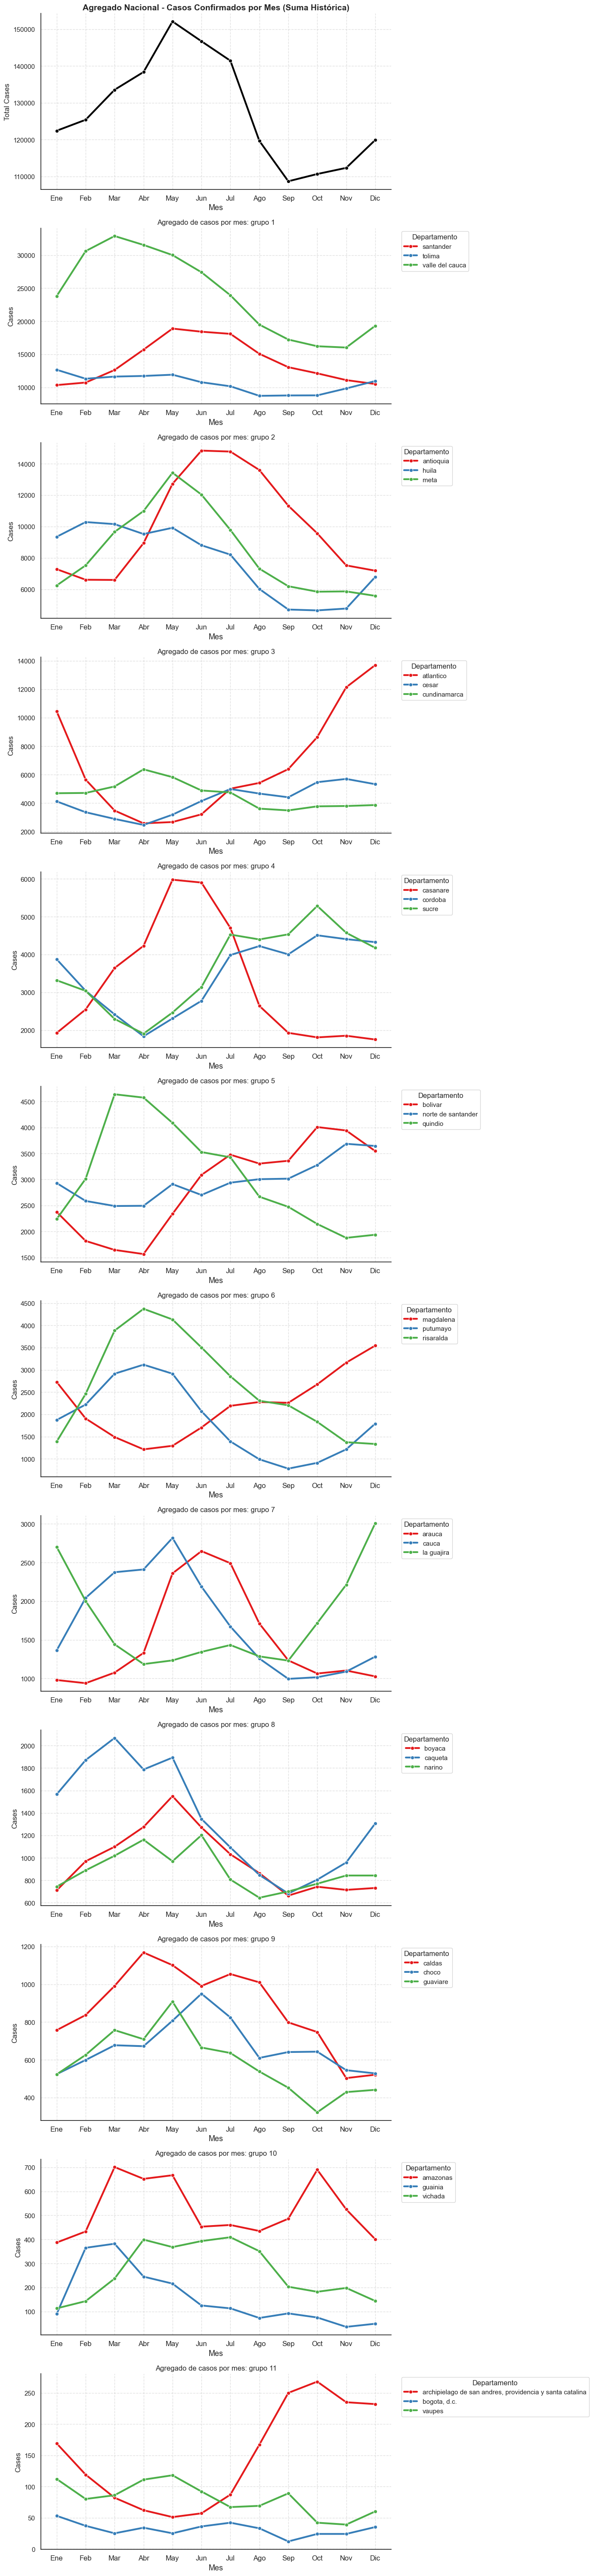

In [428]:
# Assuming 'df' and 'depto_list' are already loaded

df_clean = df.dropna(subset=['casosconfirmados']).copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['month'] = df_clean['date'].dt.month

national_agg = df_clean.groupby('month')['casosconfirmados'].sum().reset_index()

chunk_size = 3
dept_groups = [depto_list[i:i + chunk_size] for i in range(0, len(depto_list), chunk_size)]

num_plots = 1 + len(dept_groups)

# REMOVED: sharex=True. Now each subplot acts completely independently
fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(14, 5 * num_plots))

if num_plots == 1:
    axes = [axes]

meses_esp = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
custom_palette = "Set1" 

# --- PLOT 1: National Aggregate ---
sns.lineplot(
    data=national_agg, x='month', y='casosconfirmados', 
    ax=axes[0], color='black', linewidth=3, marker='o'
)
axes[0].set_title('Agregado Nacional - Casos Confirmados por Mes (Suma Histórica)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Cases')

# --- PLOTS 2+: Department Groups ---
for idx, dept_group in enumerate(dept_groups):
    ax = axes[idx + 1] 
    
    group_data = df_clean[df_clean['departamento'].isin(dept_group)]
    group_agg = group_data.groupby(['month', 'departamento'])['casosconfirmados'].sum().reset_index()
    
    sns.lineplot(
        data=group_agg, x='month', y='casosconfirmados', hue='departamento', 
        ax=ax, linewidth=3, palette=custom_palette, marker='o'
    )
    
    ax.set_title(f'Agregado de casos por mes: grupo {idx + 1}', fontsize=12)
    ax.set_ylabel('Cases')
    ax.legend(title='Departamento', bbox_to_anchor=(1.02, 1), loc='upper left')

# --- APPLY FORMATTING TO ALL PLOTS ---
# Instead of just formatting the bottom_ax, we loop through every single axis
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.6)
    sns.despine(ax=ax)
    
    # Force the 1-12 ticks and apply the Spanish labels to each graph
    ax.set_xticks(range(1, 13))              
    ax.set_xticklabels(meses_esp, fontsize=12) 
    ax.set_xlabel('Mes', fontsize=13)

plt.tight_layout()
plt.show()

In [429]:
#libs
## Librerías de visualización 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

In [430]:
# funciones para analisis exploratorio y visualizacion de datos

#* Análisis de correlación
def plot_correlation_map( df ):
    corr = df.corr()
    _ , ax = plt.subplots( figsize =( 12 , 10 ) )
    cmap = sns.diverging_palette( 220 , 10 , as_cmap = True )
    _ = sns.heatmap(
        corr, 
        cmap = cmap,
        square=True, 
        cbar_kws={ 'shrink' : .9 }, 
        ax=ax, 
        annot = True, 
        annot_kws = { 'fontsize' : 12 }
    )

def frecuencia_mensual_con_umbral(df, umbral=5000):
    #* frecuencia por meses y años en cundinamarca con años separados en diferentes subplots
    df_agrupado = df.groupby(['year', 'mes'])['casosconfirmados'].sum().reset_index()
    df_agrupado = df_agrupado.sort_values(by=['year', 'mes'])

    # 2. Configuración del estilo
    sns.set_theme(style="whitegrid")

    # 3. Creación de la cuadrícula
    g = sns.FacetGrid(df_agrupado, col="year", col_wrap=4, height=3, aspect=1.5, sharex=False, sharey=False)

    # 4. Gráfico principal (Línea de casos)
    g.map(sns.lineplot, "mes", "casosconfirmados", marker="o")

    # umbral
    g.refline(y=umbral, color="red", linestyle="--", linewidth=1.5, label="Umbral 5000")

    # 5. Ajustes finales
    g.set_axis_labels("mes", "Total Casos")
    g.set_titles(col_template="Año {col_name}")
    g.fig.suptitle("Comportamiento Mensual vs Umbral de Referencia", y=1.02)

    g.add_legend()

    plt.show()

def frecuencia_mensual_con_umbral_v2(df, umbral=5000, anos_por_subplot=1):
    """
    Genera gráficos de línea para casos confirmados.
    
    Args:
        df: DataFrame con columnas 'Year', 'Mes', 'CasosConfirmados'.
        umbral: Valor para la línea horizontal de referencia.
        anos_por_subplot: Cantidad de años continuos a mostrar en cada gráfica (ej. 2 para pares de años).
    """
    
    # 1. Agrupación inicial
    df_agrupado = df.groupby(['Year', 'Mes'])['CasosConfirmados'].sum().reset_index()
    
    # 2. Crear columna 'Fecha' para tener un Eje X continuo
    # Es vital convertir a datetime para que al graficar 2 o 3 años seguidos, 
    # la línea continúe cronológicamente y no se superpongan los meses.
    df_agrupado['Fecha'] = pd.to_datetime(
        df_agrupado['Year'].astype(str) + '-' + df_agrupado['Mes'].astype(str) + '-01'
    )
    df_agrupado = df_agrupado.sort_values('Fecha')

    # 3. Definir los bloques de años (Periodos)
    min_year = df_agrupado['Year'].min()
    
    # Calculamos un índice de bloque: (AñoActual - AñoMinimo) // N
    df_agrupado['Bloque_Indice'] = (df_agrupado['Year'] - min_year) // anos_por_subplot
    
    # Generamos etiquetas legibles para los títulos (Ej: "2007-2008")
    def generar_etiqueta(row):
        inicio = min_year + (row['Bloque_Indice'] * anos_por_subplot)
        fin = inicio + anos_por_subplot - 1
        if anos_por_subplot == 1:
            return str(inicio)
        return f"{inicio} - {fin}"

    df_agrupado['Periodo'] = df_agrupado.apply(generar_etiqueta, axis=1)

    # 4. Configuración del estilo
    sns.set_theme(style="whitegrid")

    # 5. Creación de la cuadrícula
    # Usamos 'Periodo' en col, y aumentamos el 'aspect' (ancho) para que quepan mejor las fechas
    g = sns.FacetGrid(df_agrupado, col="Periodo", col_wrap=3, height=3.5, aspect=2, sharex=False, sharey=False)

    # 6. Gráfico principal
    # Usamos 'Fecha' en el eje X en lugar de 'Mes'
    g.map(sns.lineplot, "Fecha", "CasosConfirmados", marker="o")

    # Umbral
    g.refline(y=umbral, color="red", linestyle="--", linewidth=1.5, label=f"Umbral {umbral}")

    # 7. Ajustes finales
    g.set_axis_labels("Fecha", "Total Casos")
    g.set_titles(col_template="{col_name}")
    g.fig.suptitle(f"Comportamiento de Casos ({anos_por_subplot} años por gráfica)", y=1.02)

    # Rotación de fechas en el eje X para evitar solapamiento
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')

    g.add_legend()
    plt.show()



Text(0.5, 1.0, 'Casos confirmados de dengue por año en Colombia')

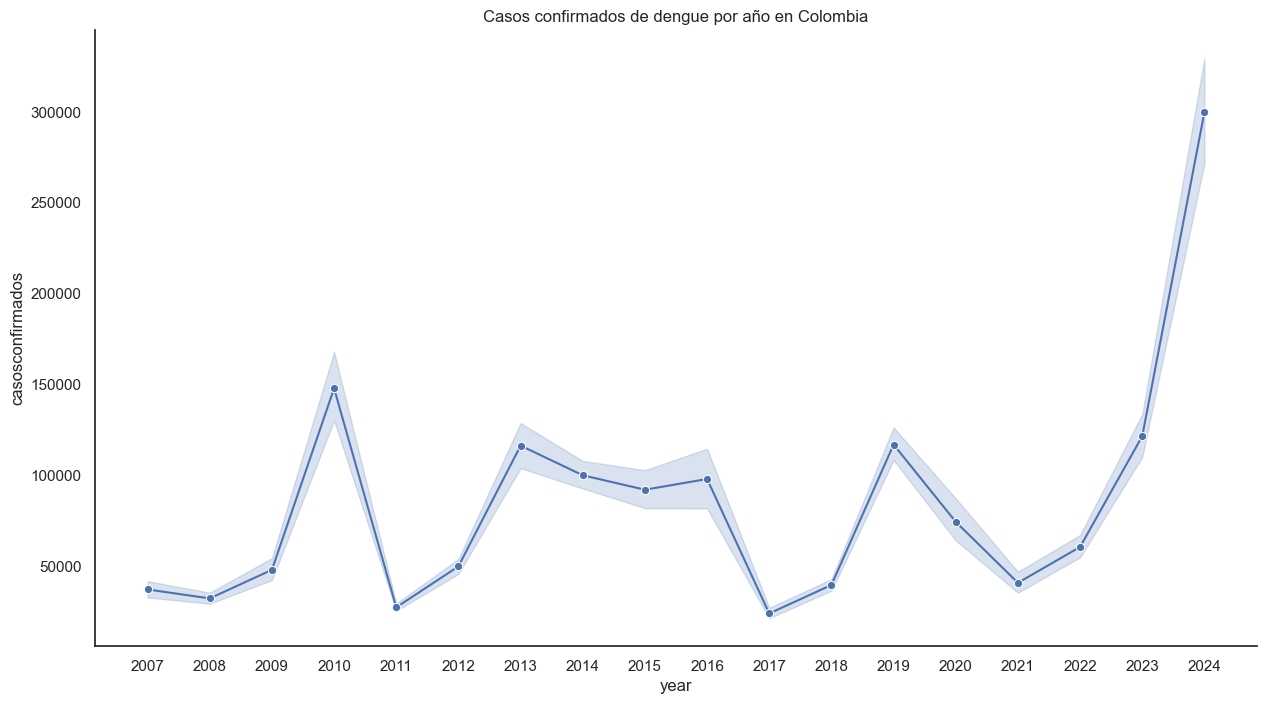

In [431]:
#* Casos confirmados por año
plt.figure(figsize=(15,8))
for col in ['year', 'mes']:
    df[col] = df[col].astype(int)
#* plotting but making year to not display decimal points in x axis
sns.lineplot(data=df, x='year', y='casosconfirmados', estimator='sum', marker='o')
plt.xticks(df['year'].unique())  # Asegura que solo se muestren los años presentes en el DataFrame

# remove borders right and top
sns.despine()
plt.title('Casos confirmados de dengue por año en Colombia')

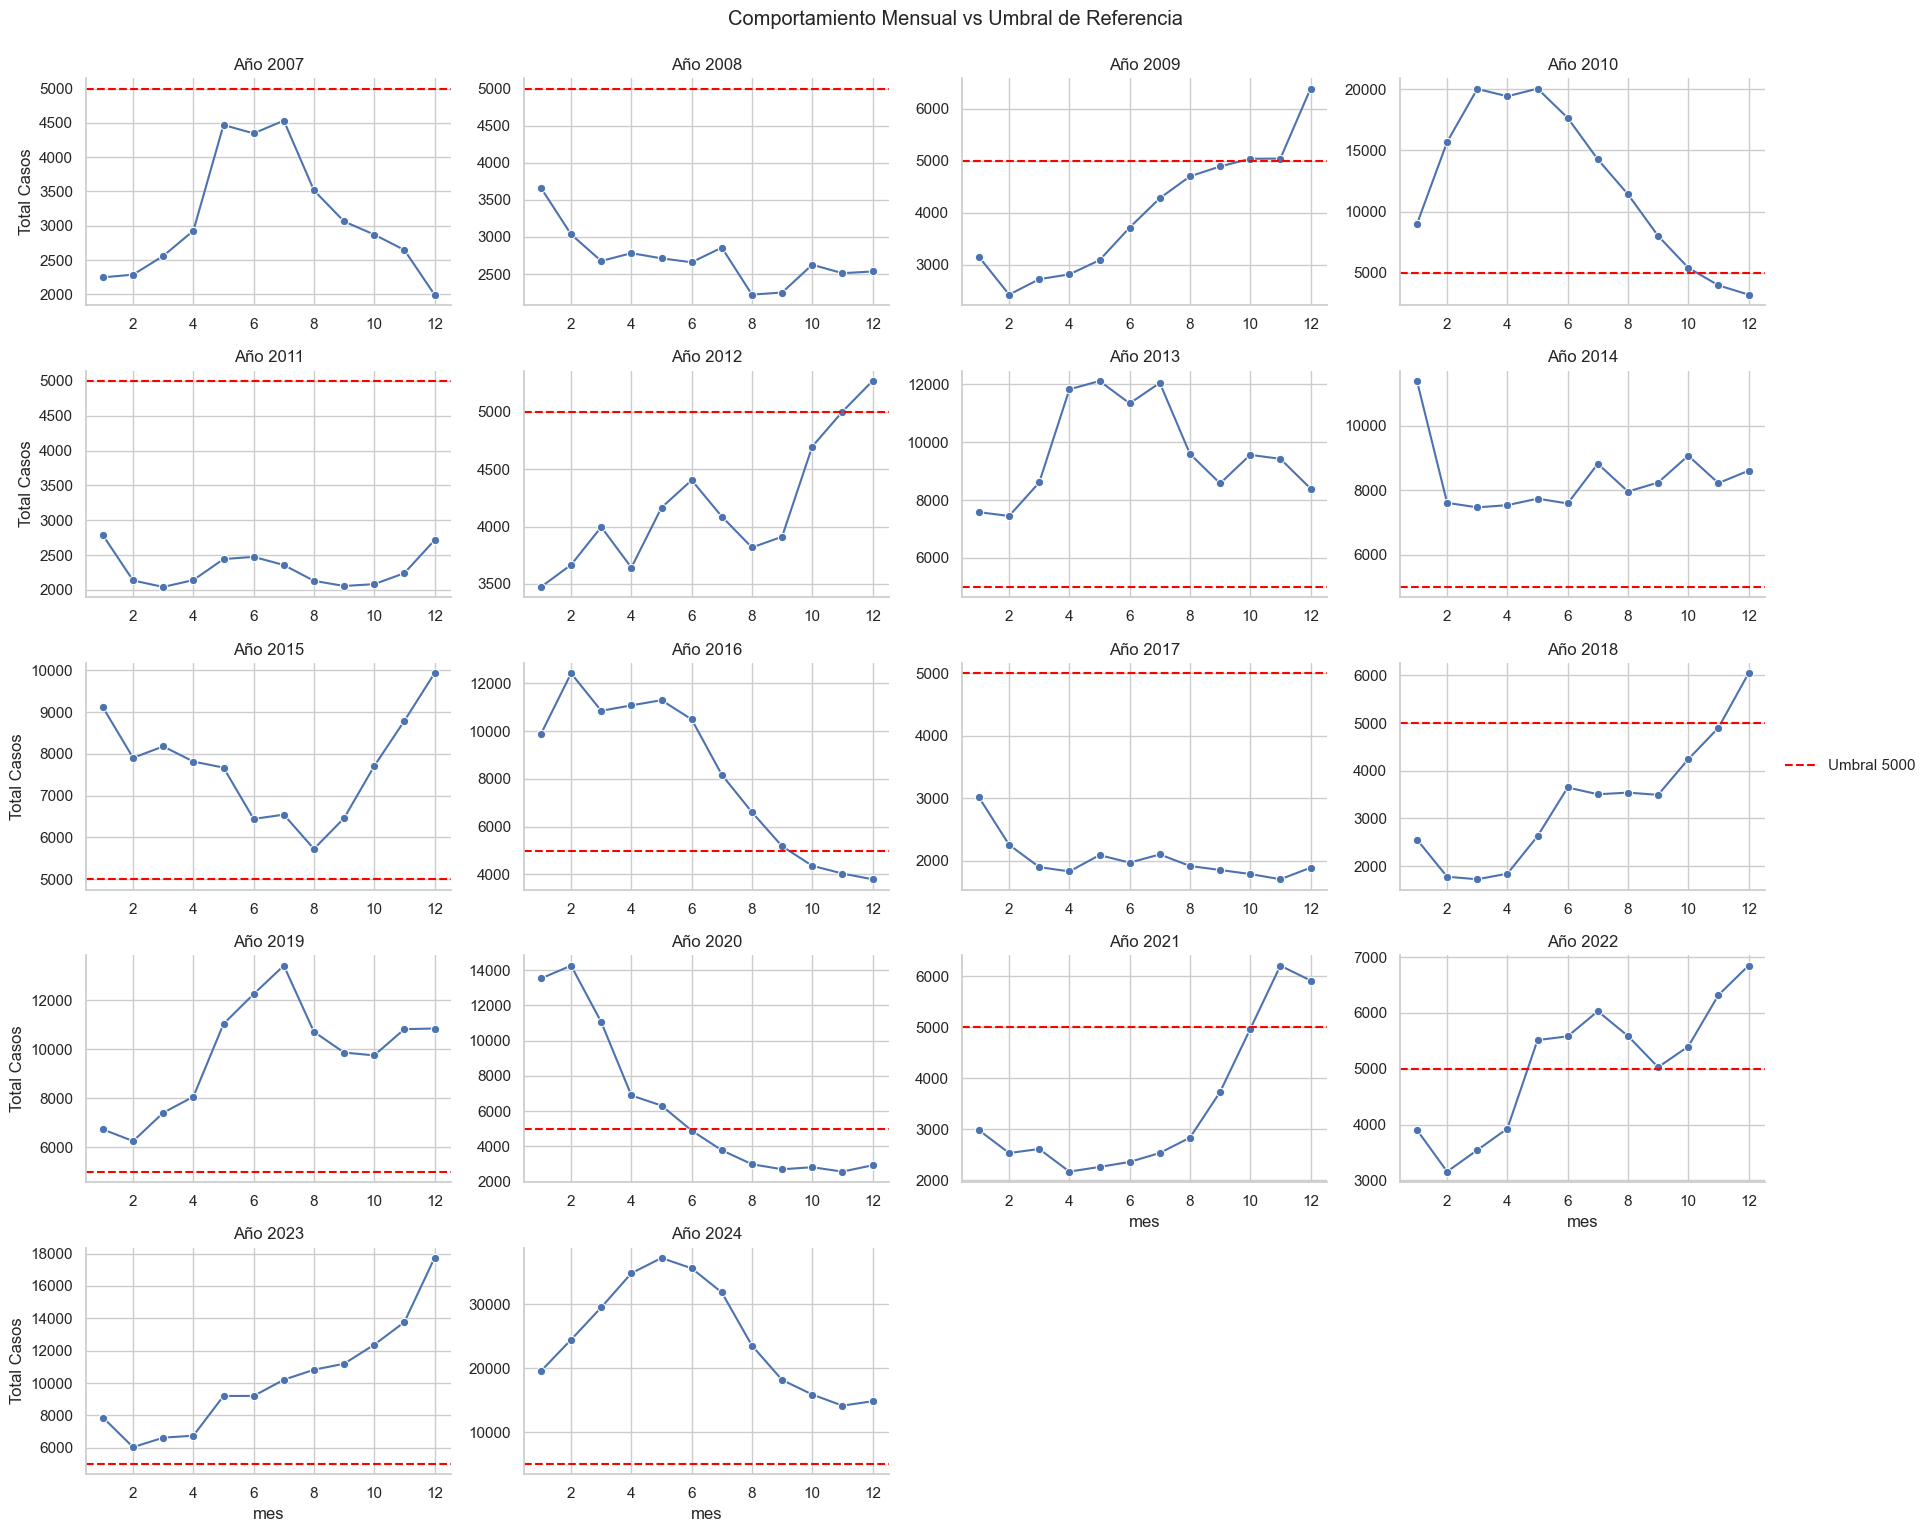

In [432]:
df['mes'] = df['mes'].apply(lambda x: int(x))
frecuencia_mensual_con_umbral(df)

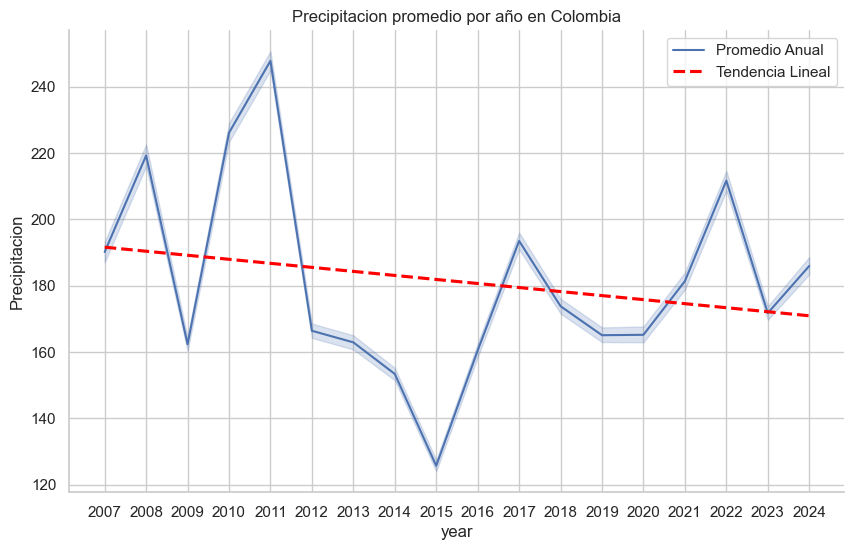

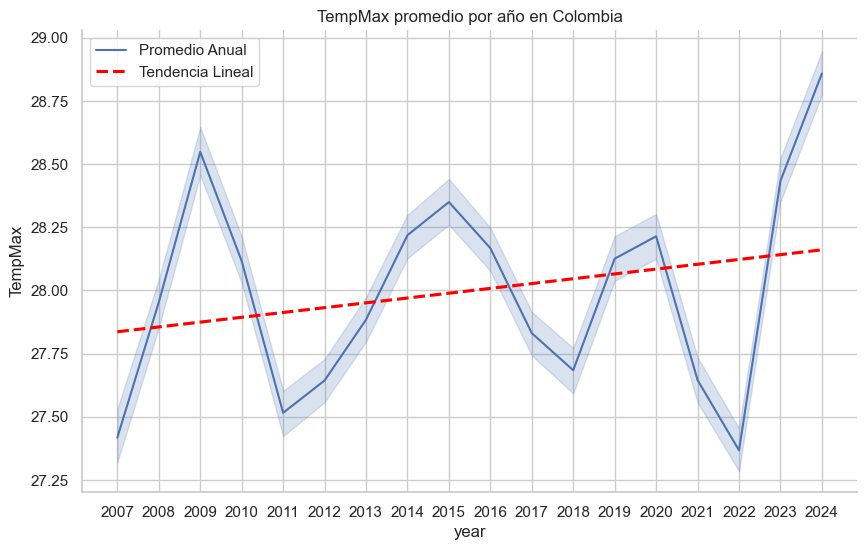

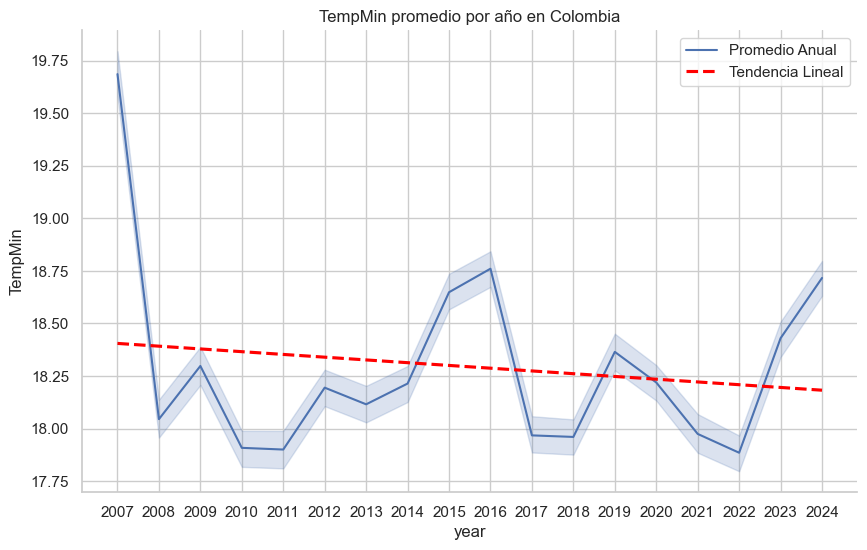

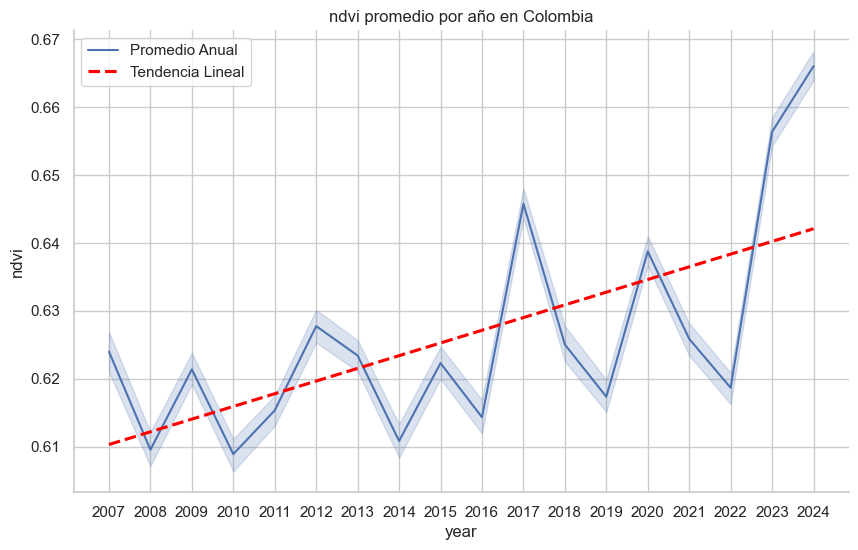

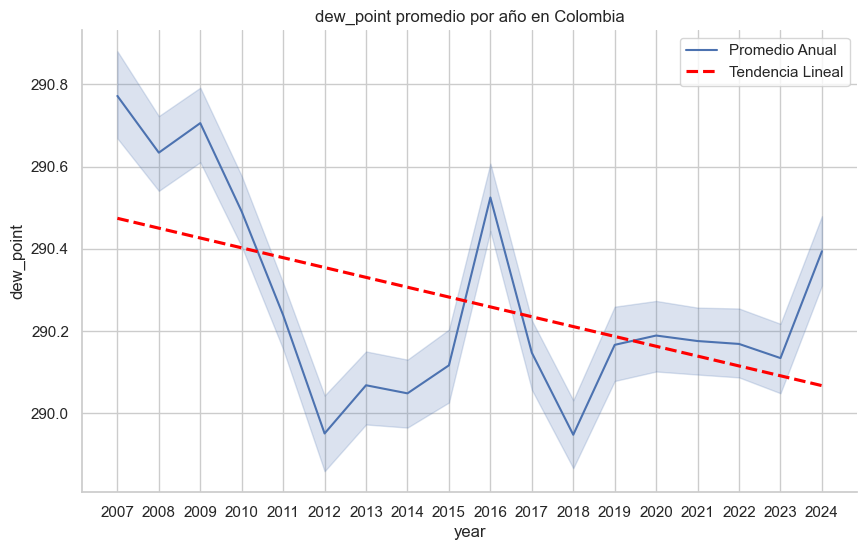

In [433]:
#* temperaturas y precipitacion promedio por año
cols = ['Precipitacion','TempMax','TempMin', 'ndvi','dew_point']
df['year'] = df['year'].astype(int)
for col in cols:
    plt.figure(figsize=(10, 6))
    
    # 1. Tu gráfica original (Línea de promedios anuales)
    sns.lineplot(data=df, x='year', y=col, estimator='mean', label='Promedio Anual')
    
    # 2. Preparar datos para la tendencia (Agrupamos por año para obtener el promedio)
    # Esto es necesario porque lineplot agrega internamente, pero para calcular la tendencia
    # necesitamos los puntos exactos (x, y) de esos promedios.
    df_trend = df.groupby('year')[col].mean().reset_index()
    
    # 3. Graficar la línea de tendencia usando regplot
    # scatter=False evita que pinte los puntos de nuevo, solo queremos la línea
    # ci=None quita la sombra del intervalo de confianza (opcional, puedes dejarlo si prefieres)
    sns.regplot(data=df_trend, x='year', y=col, scatter=False, color='red', line_kws={'linestyle':'--'}, label='Tendencia Lineal', ci=None)
    
    plt.title(f'{col} promedio por año en Colombia')
    plt.xticks(df['year'].unique())  # Asegura que solo se muestren los años presentes en el DataFrame
    plt.legend()
    sns.despine()
    plt.show()
    



In [434]:
df

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,TempMin,TempMax,Precipitacion,TempMin_lag1,TempMax_lag1,Precipitacion_lag1,TempMin_lag2,TempMax_lag2,Precipitacion_lag2,TempMin_lag3,TempMax_lag3,Precipitacion_lag3,TempMin_lag4,TempMax_lag4,Precipitacion_lag4,TempMin_lag5,TempMax_lag5,Precipitacion_lag5,TempMin_lag6,TempMax_lag6,Precipitacion_lag6,TempMin_lag7,TempMax_lag7,Precipitacion_lag7,TempMin_lag8,TempMax_lag8,Precipitacion_lag8,fenomeno,fenomeno_lag1,fenomeno_lag2,fenomeno_lag3,fenomeno_lag4,fenomeno_lag5,fenomeno_lag6,fenomeno_lag7,fenomeno_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,dew_point_lag1,dew_point_lag2,dew_point_lag3,dew_point_lag4,dew_point_lag5,dew_point_lag6,dew_point_lag7,dew_point_lag8
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,31,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,22.0,30.0,349.8,21.0,30.0,517.3,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,neutral,0.684223,296.842620,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,0.683242,0.734843,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587,295.714506,295.159026
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,23,32,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,22.0,30.0,349.8,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,0.843376,294.861824,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,0.683242,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587,295.714506
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,30,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,0.674553,296.632086,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,30,538.6,22.0,30.0,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,0.645978,296.664865,0.674553,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,296.632086,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,29,392.1,22.0,30.0,538.6,22.0,30.0,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,0.644849,295.803289,0.645978,0.674553,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,296.664865,296.632086,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202171,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,22,31,255.6,23.0,30.0,325.7,22.0,29.0,431.9,24.0,31.0,340.8,23.0,33.0,231.1,23.0,35.0,70.7,24.0,36.0,31.3,22.0,35.0,15.9,23.0,32.0,37.8,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev,nino_sev,0.664978,295.258564,0.511568,0.584245,0.684736,0.601316,0.590652,0.59000

In [435]:
df.to_csv(f'data/dengue_data_v3_{hoja_start}.csv', index=False, sep='|')

#* Eliminar filas con nan en las columnas de los rezagos, ya que no se pueden usar para graficar
lag_cols = [col for col in df.columns if 'lag' in col]
df.dropna(subset=lag_cols, inplace=True)

In [436]:
# df_lag agrupado por mes en un año especifico
df_lag_2 = df[df['year'] == 2023]
df_lag_2 = df_lag_2.groupby(['year', 'mes'])[['casosconfirmados',
                                   'Precipitacion_lag1', 'TempMax_lag1', 'TempMin_lag1',
                                   'Precipitacion_lag2', 'TempMax_lag2', 'TempMin_lag2',
                                   'Precipitacion_lag3', 'TempMax_lag3', 'TempMin_lag3']].agg({'casosconfirmados': 'sum',
                                                                                              'Precipitacion_lag1': 'mean', 'TempMax_lag1': 'mean', 'TempMin_lag1': 'mean',
                                                                                              'Precipitacion_lag2': 'mean', 'TempMax_lag2': 'mean', 'TempMin_lag2': 'mean',
                                                                                              'Precipitacion_lag3': 'mean', 'TempMax_lag3': 'mean', 'TempMin_lag3': 'mean'}).reset_index(drop=False)

In [437]:
# normalizar variables no temporales
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_lag_2[['Precipitacion_lag1', 'TempMax_lag1', 'TempMin_lag1']] = scaler.fit_transform(df_lag_2[['Precipitacion_lag1', 'TempMax_lag1', 'TempMin_lag1']])
df_lag_2[['Precipitacion_lag2', 'TempMax_lag2', 'TempMin_lag2']] = scaler.fit_transform(df_lag_2[['Precipitacion_lag2', 'TempMax_lag2', 'TempMin_lag2']])
df_lag_2[['Precipitacion_lag3', 'TempMax_lag3', 'TempMin_lag3']] = scaler.fit_transform(df_lag_2[['Precipitacion_lag3', 'TempMax_lag3', 'TempMin_lag3']])

df_lag_2['casosconfirmados'] = scaler.fit_transform(df_lag_2[['casosconfirmados']])

df_lag_2

,year,mes,casosconfirmados,Precipitacion_lag1,TempMax_lag1,TempMin_lag1,Precipitacion_lag2,TempMax_lag2,TempMin_lag2,Precipitacion_lag3,TempMax_lag3,TempMin_lag3
0,2023,1,-0.980135,-1.280885,-1.559771,-1.509129,1.928974,-2.128126,-0.880943,1.692918,-1.122434,-0.053923
1,2023,2,-1.354159,-0.159989,-1.186669,-2.035213,-1.234727,-1.044079,-1.351156,1.783297,-1.890000,-0.849994
2,2023,3,-1.073723,-1.888451,0.369863,-1.135848,-0.321125,-0.755400,-1.861612,-1.201835,-0.868940,-1.322529
3,2023,4,-0.992243,-0.018981,-0.560947,-0.031289,-1.729932,0.448930,-0.988965,-0.339799,-0.597035,-1.835505
4,2023,5,-0.196747,1.238479,-0.998175,0.400930,-0.206194,-0.271262,0.082781,-1.669089,0.537319,-0.958549
5,2023,6,-0.201983,0.921640,-0.014898,1.560063,0.818715,-0.609558,0.502160,-0.231355,-0.141027,0.118488
6,2023,7,0.077799,-0.156357,0.090037,0.758930,0.560472,0.151230,1.626859,0.735705,-0.459666,0.539938
7,2023,8,0.268574,0.202594,1.034449,0.887723,-0.318165,0.232421,0.849525,0.492038,0.256917,1.670189
8,2023,9,0.378850,0.207384,1.493053,0.331077,-0.025597,0.963138,0.974491,-0.337006,0.333391,0.889017
9,2023,10,0.732913,-0.767038,1.792311,0.171723,-0.021693,1.317972,0.434382,-0.060952,1.021650,1.014601


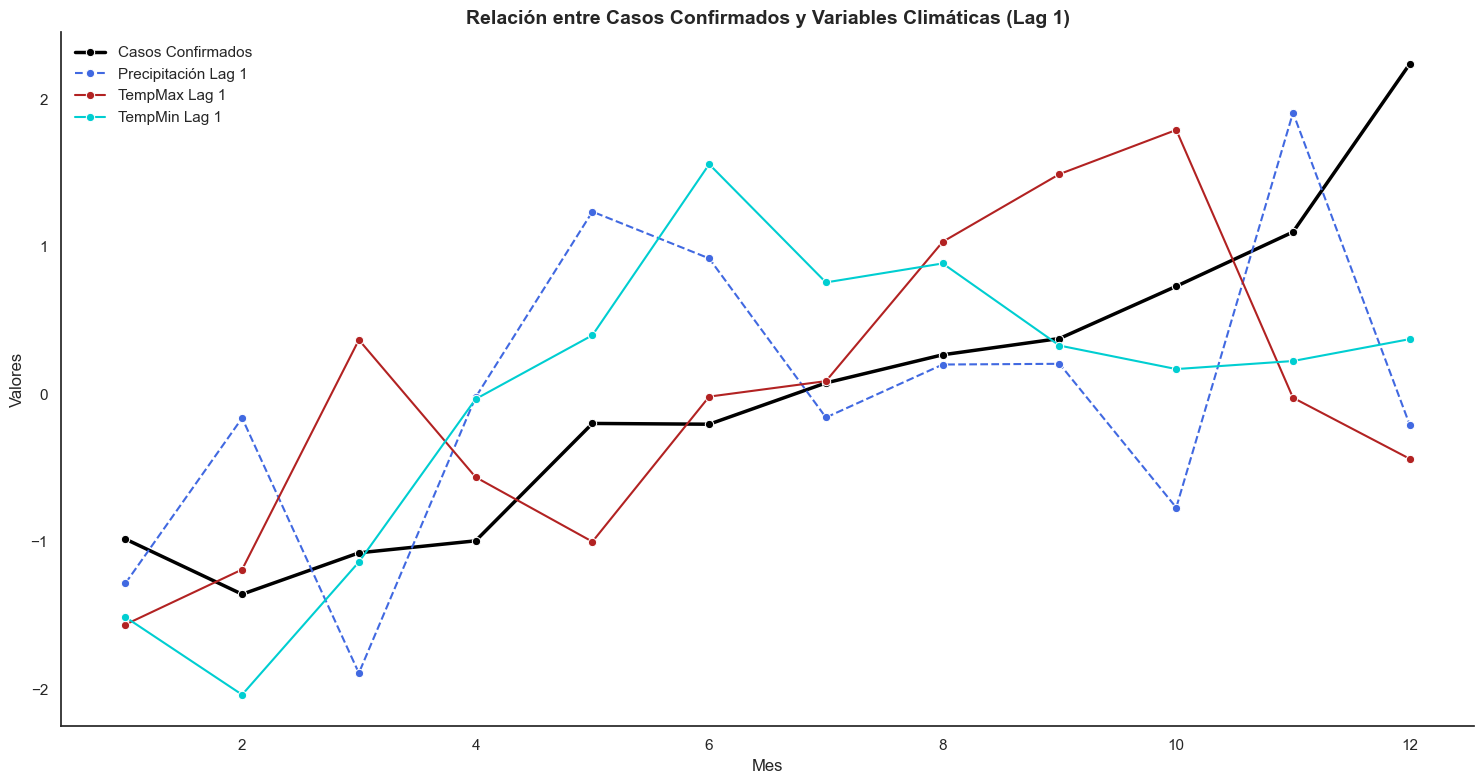

In [438]:
# line graph of CasosConfirmados vs Precipitacion_Lag1, TempMax_Lag1 and TempMin_Lag1
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='mes', y='casosconfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='mes', y='Precipitacion_lag1', 
             marker='o', label='Precipitación Lag 1', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='mes', y='TempMax_lag1', 
             marker='o', label='TempMax Lag 1', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='mes', y='TempMin_lag1', 
             marker='o', label='TempMin Lag 1', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 1)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()



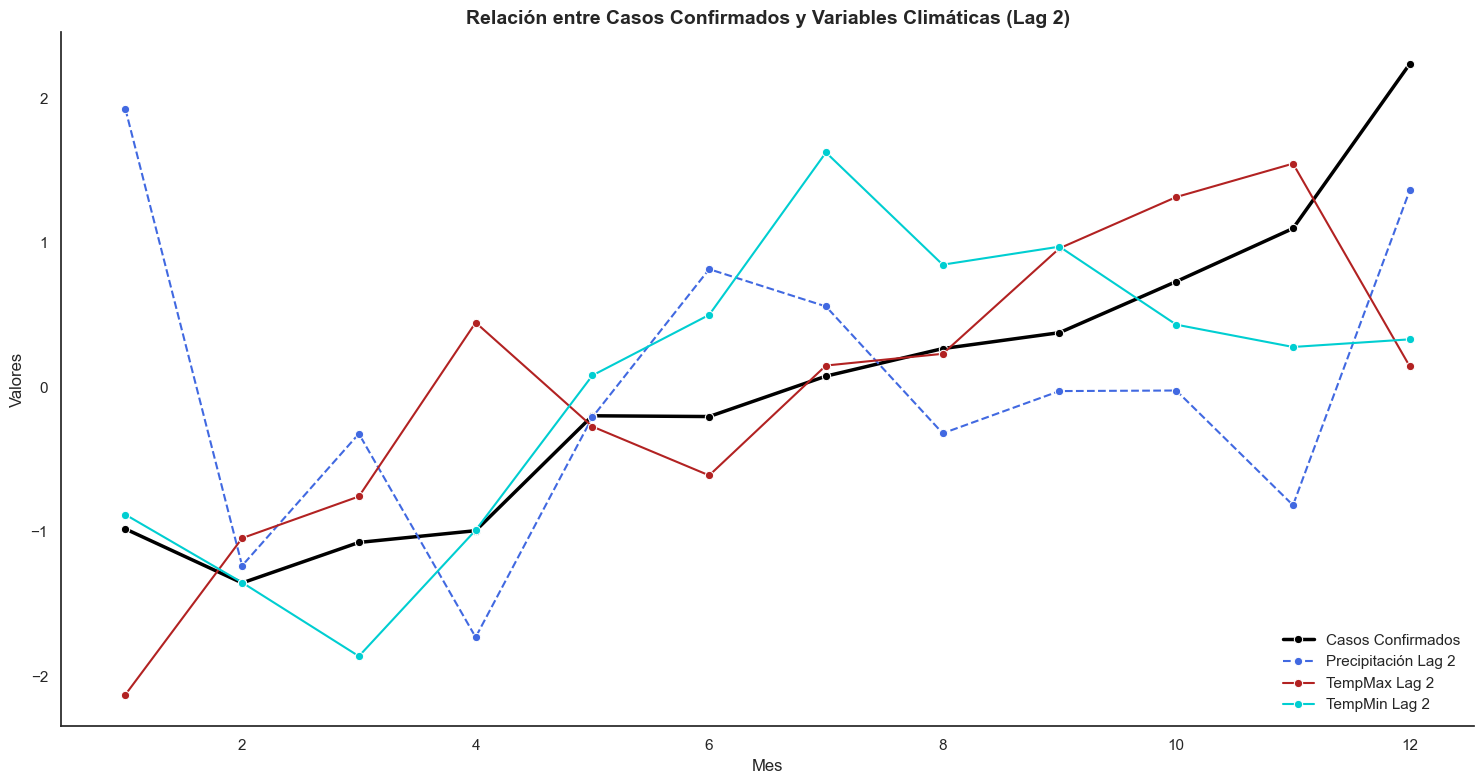

In [439]:
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='mes', y='casosconfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='mes', y='Precipitacion_lag2', 
             marker='o', label='Precipitación Lag 2', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='mes', y='TempMax_lag2', 
             marker='o', label='TempMax Lag 2', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='mes', y='TempMin_lag2', 
             marker='o', label='TempMin Lag 2', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 2)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()

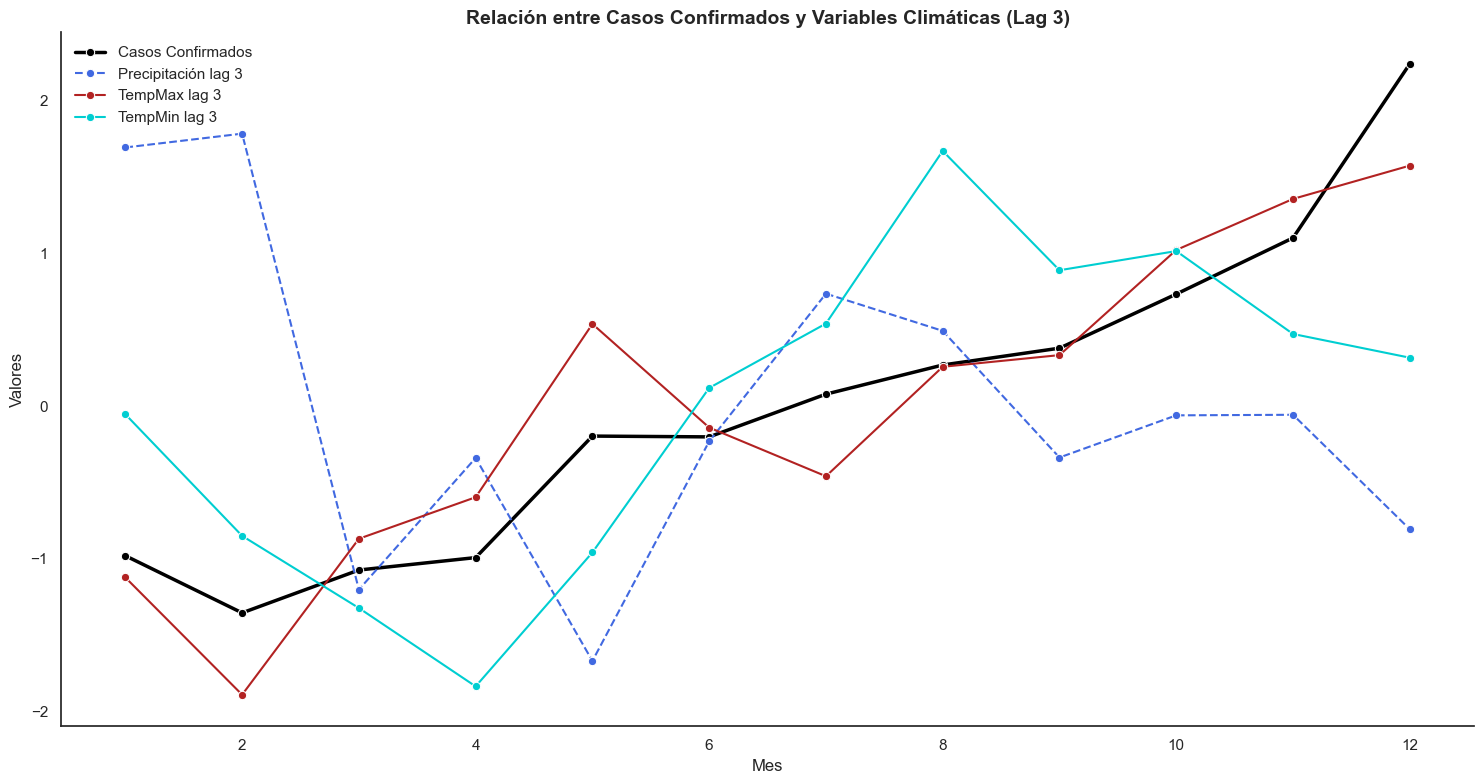

In [440]:
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='mes', y='casosconfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='mes', y='Precipitacion_lag3', 
             marker='o', label='Precipitación lag 3', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='mes', y='TempMax_lag3', 
             marker='o', label='TempMax lag 3', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='mes', y='TempMin_lag3', 
             marker='o', label='TempMin lag 3', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 3)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()

## 3. Modelado de datos

En esta sección se realizan cambios importantes en el Data set, pues se prepara para su uso en modelamiento, uno de los primeros cambios viene tras la identificación de los vacios propios en los registros de cada municipio, para ser precisos se buscaba identificar que municipios presentaban registros con saltos, es decir, que para años especificos no tengan registros, la estrategia para imputar datos consiste en hacerlo sobre la misma serie del municipio, esto depende de que el municipio presente datos para ese men de al menos 4 años antes de manera continua así el valor de inputación corresponde al promedio de años anteriores. Por otro lado, esta estrategia de imputación solo se aplico a municipios que se encontraban en departamentos que tuvieran la mayor cantidad de datos en buen estado con series de tiempo completas de al menos 10 años para al menos el 80% de sus municipios.

Tras la imputación lo que siguió fue preparar las variables a utilizar realizando codificación en las variables categoricas y haciendo el proceso de escalado para las variables numericas en su mayoría, por ahora se dejan separas del proceso de escalamiento a la variable objetivo 'casosconfirmados' y a las variables de localización 'latitud' y 'longitud'.

Se realiza un análisis de correlación con la data resultante, se nota que hay variables que están fuertemente correalcionadas, como lo son las temperaturas maxima y minima entre sí, cosa que persiste en sus rezagos, además la temperatura en general esta fuertemente relacionada con la elevación. Como corrección se plantea la eliminación de la variable de elevacion y en cambia se va a suavizar la temperatura tomando un valor medio entre la temperatura max y minima.

In [441]:
df = pd.read_csv(f'data/dengue_data_v3_{hoja_start}.csv', sep='|')
df

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,TempMin,TempMax,Precipitacion,TempMin_lag1,TempMax_lag1,Precipitacion_lag1,TempMin_lag2,TempMax_lag2,Precipitacion_lag2,TempMin_lag3,TempMax_lag3,Precipitacion_lag3,TempMin_lag4,TempMax_lag4,Precipitacion_lag4,TempMin_lag5,TempMax_lag5,Precipitacion_lag5,TempMin_lag6,TempMax_lag6,Precipitacion_lag6,TempMin_lag7,TempMax_lag7,Precipitacion_lag7,TempMin_lag8,TempMax_lag8,Precipitacion_lag8,fenomeno,fenomeno_lag1,fenomeno_lag2,fenomeno_lag3,fenomeno_lag4,fenomeno_lag5,fenomeno_lag6,fenomeno_lag7,fenomeno_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,dew_point_lag1,dew_point_lag2,dew_point_lag3,dew_point_lag4,dew_point_lag5,dew_point_lag6,dew_point_lag7,dew_point_lag8
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,31,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,22.0,30.0,349.8,21.0,30.0,517.3,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,neutral,0.684223,296.842620,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,0.683242,0.734843,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587,295.714506,295.159026
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,23,32,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,22.0,30.0,349.8,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,0.843376,294.861824,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,0.683242,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587,295.714506
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,30,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,0.674553,296.632086,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,30,538.6,22.0,30.0,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,0.645978,296.664865,0.674553,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,296.632086,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,29,392.1,22.0,30.0,538.6,22.0,30.0,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,0.644849,295.803289,0.645978,0.674553,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,296.664865,296.632086,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201775,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,22,31,255.6,23.0,30.0,325.7,22.0,29.0,431.9,24.0,31.0,340.8,23.0,33.0,231.1,23.0,35.0,70.7,24.0,36.0,31.3,22.0,35.0,15.9,23.0,32.0,37.8,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev,nino_sev,0.664978,295.258564,0.511568,0.584245,0.684736,0.601316,0.590652,0.59000

In [442]:
# verificacion de cuantos municipios por departamento tienen una serie completa de datos (2007-2024) para cada mes
# depts = ['valle del cauca','santander','tolima', 'antioquia', 'meta', 'huila','norte de santander','atlantico','bolivar','cesar']
# depts = ['cundinamarca', 'boyaca']
depts = df['departamento'].unique()
depts_full = []
depts_15 = []
depts_12 = []
depts_10 = []
for dept in depts:
# dept = 'antioquia'
    df_dept = df[df['departamento'] == dept]
    df_dept['year'] = df_dept['year'].astype(int)

    full = [] #18*12
    al_menos_15 = [] #15*12
    al_menos_12 = [] #12*12
    al_menos_10 = [] #10*12
    al_menos_5 =[] #5*12
    menos_de_5 = [] #menos de 5*12
    for muni in df_dept['municipio'].unique():
        df_muni = df_dept[df_dept['municipio'] == muni]
        count = df_muni.groupby(['year', 'mes']).size().reset_index(name='Count')
        # count if not nan values in CasosConfirmados column
        count = df_muni[~df_muni['casosconfirmados'].isna()].groupby(['year', 'mes']).size().reset_index(name='Count')
        count_total = count['Count'].sum()
        if count_total == (18*12): 
            full.append(muni)
        elif count_total >= 15*12:
            al_menos_15.append(muni)
        elif count_total >= 12*12:
            al_menos_12.append(muni)
        elif count_total >= 10*12:
            al_menos_10.append(muni)
        elif count_total >= 5*12:
            al_menos_5.append(muni)
        else:
            menos_de_5.append(muni)
        del df_muni, count
    #* si el departamente tiene un 80% o mas de sus municipios con serie completa de datos, agregarlo a la lista de departamentos con buena cobertura
    if len(full)/len(df_dept['municipio'].unique()) >= 0.8:
        depts_full.append(dept)
    if len(al_menos_15+full)/len(df_dept['municipio'].unique()) >= 0.8:
        depts_15.append(dept)
    if len(al_menos_12+al_menos_15+full)/len(df_dept['municipio'].unique()) >= 0.8:
        depts_12.append(dept)
    if len(al_menos_10+al_menos_12+al_menos_15+full)/len(df_dept['municipio'].unique()) >= 0.8:
        depts_10.append(dept)

    print(f"Municipios del {dept} con serie completa de datos (18 años): {len(full)/len(df_dept['municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 15 años de datos: {len(al_menos_15)/len(df_dept['municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 12 años de datos: {len(al_menos_12)/len(df_dept['municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 10 años de datos: {len(al_menos_10)/len(df_dept['municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con al menos 5 años de datos: {len(al_menos_5)/len(df_dept['municipio'].unique())*100:.2f}%")
    print(f"Municipios del {dept} con menos de 5 años de datos: {len(menos_de_5)/len(df_dept['municipio'].unique())*100:.2f}%")
    print("\n")

Municipios del amazonas con serie completa de datos (18 años): 9.09%
Municipios del amazonas con al menos 15 años de datos: 0.00%
Municipios del amazonas con al menos 12 años de datos: 9.09%
Municipios del amazonas con al menos 10 años de datos: 9.09%
Municipios del amazonas con al menos 5 años de datos: 27.27%
Municipios del amazonas con menos de 5 años de datos: 45.45%


Municipios del antioquia con serie completa de datos (18 años): 11.57%
Municipios del antioquia con al menos 15 años de datos: 32.23%
Municipios del antioquia con al menos 12 años de datos: 20.66%
Municipios del antioquia con al menos 10 años de datos: 10.74%
Municipios del antioquia con al menos 5 años de datos: 20.66%
Municipios del antioquia con menos de 5 años de datos: 4.13%


Municipios del arauca con serie completa de datos (18 años): 71.43%
Municipios del arauca con al menos 15 años de datos: 28.57%
Municipios del arauca con al menos 12 años de datos: 0.00%
Municipios del arauca con al menos 10 años de datos:

In [443]:
# depts_full
# depts_15
# depts_12
depts_10

['arauca',
 'archipielago de san andres, providencia y santa catalina',
 'atlantico',
 'bolivar',
 'caqueta',
 'casanare',
 'cesar',
 'choco',
 'cordoba',
 'guaviare',
 'huila',
 'la guajira',
 'magdalena',
 'meta',
 'norte de santander',
 'quindio',
 'risaralda',
 'santander',
 'sucre',
 'tolima',
 'valle del cauca',
 'vichada']

In [444]:
discontinuos = {}
for dept in depts_10:
    df_dept = df[df['departamento'] == dept]
    for muni in df_dept['municipio'].unique():
        años = []
        df_muni = df_dept[df_dept['municipio'] == muni]    
        #* tomamos el minimo año y el maximo por en el municipio para identificar si hay saltos de meses o años en la serie de datos
        min_year = df_muni['year'].min()
        max_year = df_muni['year'].max()
        #* identificar municipios que tienen salto de mes en algn año
        for year in range(min_year, max_year+1):
            df_year = df_muni[df_muni['year'] == year]
            #* si el año es el primero de la serie, esperamos que no tenga los primeros 3 meses por los rezagos, pero si el año es el ultimo de la serie, esperamos que no tenga los ultimos 3 meses por los rezagos, en caso contrario, esperamos que tenga los 12 meses
            meses_esperados = set(range(1,13))
            #* meses presentes son sin nan en CasosConfirmados
            # meses_presentes = set(df_year['Mes'].unique())
            meses_presentes = set(df_year[~df_year['casosconfirmados'].isna()]['mes'].unique())
            if meses_esperados != meses_presentes:
                #* si faltan todos los meses 
                if len(meses_presentes) == 0:
                    print(f"El municipio {muni} en el departamento {dept} no tiene datos para el año {year}.")
                else:
                    print(f"El municipio {muni} en el departamento {dept} tiene salto de meses en el año {year}. Meses faltantes: {meses_esperados-meses_presentes}")
                años.append(year)
        if len(años) > 0:
            if dept not in discontinuos:
                discontinuos[f"{dept}"] = {f"{muni}": años}
            else:
                discontinuos[f"{dept}"][f"{muni}"] = años

El municipio cravo norte en el departamento arauca no tiene datos para el año 2020.
El municipio cravo norte en el departamento arauca no tiene datos para el año 2022.
El municipio puerto rondon en el departamento arauca no tiene datos para el año 2016.
El municipio puerto rondon en el departamento arauca no tiene datos para el año 2020.
El municipio puerto rondon en el departamento arauca no tiene datos para el año 2021.
El municipio providencia en el departamento archipielago de san andres, providencia y santa catalina no tiene datos para el año 2008.
El municipio providencia en el departamento archipielago de san andres, providencia y santa catalina no tiene datos para el año 2009.
El municipio providencia en el departamento archipielago de san andres, providencia y santa catalina no tiene datos para el año 2010.
El municipio providencia en el departamento archipielago de san andres, providencia y santa catalina no tiene datos para el año 2011.
El municipio providencia en el departa

In [445]:
# Calcular perdida de datos por departamento considerando los municipios con saltos
perdida_por_dept = {}
for dept, munis in discontinuos.items():
    total_municipios = len(df[df['departamento'] == dept]['municipio'].unique())
    municipios_con_saltos = len(munis)
    perdida_por_dept[dept] = (municipios_con_saltos / total_municipios) * 100
    print(f"Departamento: {dept}, Municipios con saltos: {municipios_con_saltos}/{total_municipios} ({perdida_por_dept[dept]:.2f}%)")

Departamento: arauca, Municipios con saltos: 2/7 (28.57%)
Departamento: archipielago de san andres, providencia y santa catalina, Municipios con saltos: 1/2 (50.00%)
Departamento: atlantico, Municipios con saltos: 7/22 (31.82%)
Departamento: bolivar, Municipios con saltos: 26/44 (59.09%)
Departamento: caqueta, Municipios con saltos: 12/16 (75.00%)
Departamento: casanare, Municipios con saltos: 4/19 (21.05%)
Departamento: cesar, Municipios con saltos: 3/24 (12.50%)
Departamento: choco, Municipios con saltos: 26/31 (83.87%)
Departamento: cordoba, Municipios con saltos: 8/28 (28.57%)
Departamento: guaviare, Municipios con saltos: 1/4 (25.00%)
Departamento: huila, Municipios con saltos: 9/37 (24.32%)
Departamento: la guajira, Municipios con saltos: 6/15 (40.00%)
Departamento: magdalena, Municipios con saltos: 19/28 (67.86%)
Departamento: meta, Municipios con saltos: 6/29 (20.69%)
Departamento: norte de santander, Municipios con saltos: 21/39 (53.85%)
Departamento: quindio, Municipios con s

In [446]:
# 1. Safer way to identify variables (avoiding metadata/time columns)
exclude_cols = ['departamento', 'municipio', 'year', 'mes', 'tipomunicipio', 'longitud', 'latitud', 'cod_muni', 'date']
vars_to_impute = [c for c in df.columns if c not in exclude_cols]
vars_to_impute =['casosconfirmados']  # Focusing on the main target variable for imputation
for dept in depts_10:
    df_dept = df[df['departamento'] == dept]
    for muni in df_dept['municipio'].unique():
        # Get a slice for the current municipality
        df_muni = df_dept[df_dept['municipio'] == muni]
        
        # Get basic info
        min_year = df_muni['year'].min()
        
        # 2. Identify indices where CasosConfirmados is NaN 
        # (Assuming these rows were created by your grid completion step)
        nan_indices = df_muni[df_muni['casosconfirmados'].isna()].index
        
        for idx in nan_indices:
            # Retrieve the row data from the main DF using the index
            row = df.loc[idx]
            year = row['year']
            mes = row['mes']
            
            # Logic check: Only impute if it meets your "expected months" criteria 
            # (e.g., month >= 4 if it's the first year)
            if year == min_year and mes < 4:
                continue
                
            # 3. Filter historical data for the same month across previous years
            # We ensure we only use rows that HAVE data (notna) to calculate the mean
            df_hist = df_muni[
                (df_muni['year'] < year) & 
                (df_muni['mes'] == mes) & 
                (df_muni['casosconfirmados'].notna())
            ]
            
            if len(df_hist) >= 4:
                # 4. Impute values directly into the existing row in the main 'df'
                for v in vars_to_impute:
                    mean_val = df_hist[v].astype(float).mean()
                    df.loc[idx, v] = mean_val
                
                print(f"Imputado: {muni} ({dept}) para {year}-{mes} usando {len(df_hist)} años previos.")
            else:
                print(f"No se pudo imputar: {muni} ({dept}) para {year}-{mes} (Datos insuficientes: {len(df_hist)})")


Imputado: cravo norte (arauca) para 2020-1 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-2 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-3 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-4 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-5 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-6 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-7 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-8 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-9 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-10 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-11 usando 12 años previos.
Imputado: cravo norte (arauca) para 2020-12 usando 12 años previos.
Imputado: cravo norte (arauca) para 2022-1 usando 13 años previos.
Imputado: cravo norte (arauca) para 2022-2 usando 13 años previos.
Imputado: cravo norte (arauca) para 2022-3 usando 13 años p

Imputado: puerto rondon (arauca) para 2016-7 usando 9 años previos.
Imputado: puerto rondon (arauca) para 2016-8 usando 9 años previos.
Imputado: puerto rondon (arauca) para 2016-9 usando 9 años previos.
Imputado: puerto rondon (arauca) para 2016-10 usando 9 años previos.
Imputado: puerto rondon (arauca) para 2016-11 usando 9 años previos.
Imputado: puerto rondon (arauca) para 2016-12 usando 9 años previos.
Imputado: puerto rondon (arauca) para 2020-1 usando 12 años previos.
Imputado: puerto rondon (arauca) para 2020-2 usando 12 años previos.
Imputado: puerto rondon (arauca) para 2020-3 usando 12 años previos.
Imputado: puerto rondon (arauca) para 2020-4 usando 12 años previos.
Imputado: puerto rondon (arauca) para 2020-5 usando 12 años previos.
Imputado: puerto rondon (arauca) para 2020-6 usando 12 años previos.
Imputado: puerto rondon (arauca) para 2020-7 usando 12 años previos.
Imputado: puerto rondon (arauca) para 2020-8 usando 12 años previos.
Imputado: puerto rondon (arauca) para

In [447]:
df

,departamento,municipio,date,pais,year,mes,casosconfirmados,cod_muni,tipo,longitud,latitud,elevacion,TempMin,TempMax,Precipitacion,TempMin_lag1,TempMax_lag1,Precipitacion_lag1,TempMin_lag2,TempMax_lag2,Precipitacion_lag2,TempMin_lag3,TempMax_lag3,Precipitacion_lag3,TempMin_lag4,TempMax_lag4,Precipitacion_lag4,TempMin_lag5,TempMax_lag5,Precipitacion_lag5,TempMin_lag6,TempMax_lag6,Precipitacion_lag6,TempMin_lag7,TempMax_lag7,Precipitacion_lag7,TempMin_lag8,TempMax_lag8,Precipitacion_lag8,fenomeno,fenomeno_lag1,fenomeno_lag2,fenomeno_lag3,fenomeno_lag4,fenomeno_lag5,fenomeno_lag6,fenomeno_lag7,fenomeno_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,dew_point_lag1,dew_point_lag2,dew_point_lag3,dew_point_lag4,dew_point_lag5,dew_point_lag6,dew_point_lag7,dew_point_lag8
0,amazonas,el encanto,2007-01-01,colombia,2007,1,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,31,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,22.0,30.0,349.8,21.0,30.0,517.3,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,neutral,0.684223,296.842620,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,0.683242,0.734843,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587,295.714506,295.159026
1,amazonas,el encanto,2007-02-01,colombia,2007,2,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,23,32,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,22.0,30.0,349.8,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,0.843376,294.861824,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,0.683242,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587,295.714506
2,amazonas,el encanto,2007-03-01,colombia,2007,3,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,30,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,21.0,29.0,183.1,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,0.674553,296.632086,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,0.810195,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095,295.652587
3,amazonas,el encanto,2007-04-01,colombia,2007,4,0.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,30,538.6,22.0,30.0,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,21.0,31.0,368.3,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,0.645978,296.664865,0.674553,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,0.802718,296.632086,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428,296.118095
4,amazonas,el encanto,2007-05-01,colombia,2007,5,2.0,91263,Área no municipalizada,-73.207114,-1.748060,158,22,29,392.1,22.0,30.0,538.6,22.0,30.0,568.9,23.0,32.0,144.6,22.0,31.0,391.1,22.0,31.0,199.1,22.0,31.0,337.7,22.0,31.0,388.7,21.0,31.0,197.2,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,0.644849,295.803289,0.645978,0.674553,0.843376,0.684223,0.747855,0.649506,0.822436,0.741269,296.664865,296.632086,294.861824,296.842620,296.735831,296.662447,296.885295,296.305428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201775,vichada,santa rosalia,2024-08-01,colombia,2024,8,1.0,99624,Municipio,-70.859499,5.136393,116,22,31,255.6,23.0,30.0,325.7,22.0,29.0,431.9,24.0,31.0,340.8,23.0,33.0,231.1,23.0,35.0,70.7,24.0,36.0,31.3,22.0,35.0,15.9,23.0,32.0,37.8,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev,nino_sev,0.664978,295.258564,0.511568,0.584245,0.684736,0.601316,0.590652,0.59000

In [448]:
#* eliminar filas con valores faltantes en las columnas de clima rezagadas
lag_cols = [col for col in df.columns if 'lag' in col]
df.dropna(subset=lag_cols, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 181836 entries, 0 to 201779
Data columns (total 66 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   departamento        181836 non-null  str    
 1   municipio           181836 non-null  str    
 2   date                181836 non-null  str    
 3   pais                151140 non-null  str    
 4   year                181836 non-null  int64  
 5   mes                 181836 non-null  int64  
 6   casosconfirmados    156960 non-null  float64
 7   cod_muni            181836 non-null  int64  
 8   tipo                181836 non-null  str    
 9   longitud            181836 non-null  float64
 10  latitud             181836 non-null  float64
 11  elevacion           181836 non-null  int64  
 12  TempMin             181836 non-null  int64  
 13  TempMax             181836 non-null  int64  
 14  Precipitacion       181836 non-null  float64
 15  TempMin_lag1        181836 non-null  float64
 16  

In [449]:
df = df[df['departamento'].isin(depts_10)] #* Se utilizan solo los datos de los departamentos con mejor calidad de dato
#* implica eliminar cerca de 70_000 observaciones para enfocar el análisis en los departamentos con mejor calidad de datos
df.info()


<class 'pandas.DataFrame'>
Index: 105444 entries, 24984 to 201779
Data columns (total 66 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   departamento        105444 non-null  str    
 1   municipio           105444 non-null  str    
 2   date                105444 non-null  str    
 3   pais                96516 non-null   str    
 4   year                105444 non-null  int64  
 5   mes                 105444 non-null  int64  
 6   casosconfirmados    102336 non-null  float64
 7   cod_muni            105444 non-null  int64  
 8   tipo                105444 non-null  str    
 9   longitud            105444 non-null  float64
 10  latitud             105444 non-null  float64
 11  elevacion           105444 non-null  int64  
 12  TempMin             105444 non-null  int64  
 13  TempMax             105444 non-null  int64  
 14  Precipitacion       105444 non-null  float64
 15  TempMin_lag1        105444 non-null  float64
 

In [450]:
#* eliminar columnas que no se van a usar para el analisis
df.drop(columns=['departamento','municipio','pais','date','cod_muni','tipo'], inplace=True)
df

,year,mes,casosconfirmados,longitud,latitud,elevacion,TempMin,TempMax,Precipitacion,TempMin_lag1,TempMax_lag1,Precipitacion_lag1,TempMin_lag2,TempMax_lag2,Precipitacion_lag2,TempMin_lag3,TempMax_lag3,Precipitacion_lag3,TempMin_lag4,TempMax_lag4,Precipitacion_lag4,TempMin_lag5,TempMax_lag5,Precipitacion_lag5,TempMin_lag6,TempMax_lag6,Precipitacion_lag6,TempMin_lag7,TempMax_lag7,Precipitacion_lag7,TempMin_lag8,TempMax_lag8,Precipitacion_lag8,fenomeno,fenomeno_lag1,fenomeno_lag2,fenomeno_lag3,fenomeno_lag4,fenomeno_lag5,fenomeno_lag6,fenomeno_lag7,fenomeno_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,dew_point_lag1,dew_point_lag2,dew_point_lag3,dew_point_lag4,dew_point_lag5,dew_point_lag6,dew_point_lag7,dew_point_lag8
24984,2007,1,16.0,-70.747408,7.072726,127,24,32,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,23.0,30.0,469.6,23.0,30.0,346.5,23.0,30.0,269.5,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,neutral,0.561986,291.948053,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,0.664694,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694,295.882281
24985,2007,2,30.0,-70.747408,7.072726,127,22,35,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,23.0,30.0,469.6,23.0,30.0,346.5,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,0.442583,288.149941,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694
24986,2007,3,58.0,-70.747408,7.072726,127,24,35,70.8,22.0,35.0,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,23.0,30.0,469.6,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,0.380690,291.867835,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213
24987,2007,4,41.0,-70.747408,7.072726,127,24,33,118.0,24.0,35.0,70.8,22.0,35.0,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,0.658117,296.449290,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799
24988,2007,5,83.0,-70.747408,7.072726,127,24,31,193.6,24.0,33.0,118.0,24.0,35.0,70.8,22.0,35.0,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,0.668407,296.416535,0.658117,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,296.449290,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201775,2024,8,1.0,-70.859499,5.136393,116,22,31,255.6,23.0,30.0,325.7,22.0,29.0,431.9,24.0,31.0,340.8,23.0,33.0,231.1,23.0,35.0,70.7,24.0,36.0,31.3,22.0,35.0,15.9,23.0,32.0,37.8,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev,nino_sev,0.664978,295.258564,0.511568,0.584245,0.684736,0.601316,0.590652,0.590001,0.634855,0.660294,295.258564,295.258564,295.258564,295.258564,295.258564,295.258564,295.258564,295.258564
201776,2024,9,3.0,-70.859499,5.136393,116,23,32,211.5,22.0,31.0,255.6,23.0,30.0,325.7,22.0,29.0,431.9,24.0,31.0,340.8,23.0,33.0,231.1,23.0,35.0,70.7,24.0,36.0,31.3,22.0,35.0,15.9,neutral,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_sev,0.679174,295.258564,0.664978,0.511568,0.584245,0.684736,0.601316,0.590652,0.590001,0.634855,295.258564,295.258564,295.

In [451]:
#* Se guarda df con rezagos e imputaciones para la siguiente etapa de análisis y modelado
df.to_csv(f'data/dengue_data_v4_{hoja_start}.csv', index=False, sep='|')

## 4. Análisis premodelamiento

In [468]:
df = pd.read_csv(f'data/dengue_data_v4_{hoja_start}.csv', sep='|')
df.head()

,year,mes,casosconfirmados,longitud,latitud,elevacion,TempMin,TempMax,Precipitacion,TempMin_lag1,TempMax_lag1,Precipitacion_lag1,TempMin_lag2,TempMax_lag2,Precipitacion_lag2,TempMin_lag3,TempMax_lag3,Precipitacion_lag3,TempMin_lag4,TempMax_lag4,Precipitacion_lag4,TempMin_lag5,TempMax_lag5,Precipitacion_lag5,TempMin_lag6,TempMax_lag6,Precipitacion_lag6,TempMin_lag7,TempMax_lag7,Precipitacion_lag7,TempMin_lag8,TempMax_lag8,Precipitacion_lag8,fenomeno,fenomeno_lag1,fenomeno_lag2,fenomeno_lag3,fenomeno_lag4,fenomeno_lag5,fenomeno_lag6,fenomeno_lag7,fenomeno_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,dew_point_lag1,dew_point_lag2,dew_point_lag3,dew_point_lag4,dew_point_lag5,dew_point_lag6,dew_point_lag7,dew_point_lag8
0,2007,1,16.0,-70.747408,7.072726,127,24,32,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,23.0,30.0,469.6,23.0,30.0,346.5,23.0,30.0,269.5,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,neutral,0.561986,291.948053,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,0.664694,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694,295.882281
1,2007,2,30.0,-70.747408,7.072726,127,22,35,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,23.0,30.0,469.6,23.0,30.0,346.5,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,0.442583,288.149941,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694
2,2007,3,58.0,-70.747408,7.072726,127,24,35,70.8,22.0,35.0,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,23.0,30.0,469.6,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,0.380690,291.867835,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213
3,2007,4,41.0,-70.747408,7.072726,127,24,33,118.0,24.0,35.0,70.8,22.0,35.0,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,0.658117,296.449290,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799
4,2007,5,83.0,-70.747408,7.072726,127,24,31,193.6,24.0,33.0,118.0,24.0,35.0,70.8,22.0,35.0,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,0.668407,296.416535,0.658117,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,296.449290,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899


In [469]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105444 entries, 0 to 105443
Data columns (total 60 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   year                105444 non-null  int64  
 1   mes                 105444 non-null  int64  
 2   casosconfirmados    102336 non-null  float64
 3   longitud            105444 non-null  float64
 4   latitud             105444 non-null  float64
 5   elevacion           105444 non-null  int64  
 6   TempMin             105444 non-null  int64  
 7   TempMax             105444 non-null  int64  
 8   Precipitacion       105444 non-null  float64
 9   TempMin_lag1        105444 non-null  float64
 10  TempMax_lag1        105444 non-null  float64
 11  Precipitacion_lag1  105444 non-null  float64
 12  TempMin_lag2        105444 non-null  float64
 13  TempMax_lag2        105444 non-null  float64
 14  Precipitacion_lag2  105444 non-null  float64
 15  TempMin_lag3        105444 non-null  float64


In [470]:
# make dummies for Year and Mes
df = pd.get_dummies(df, columns=['mes'] + [i for i in df.columns if 'fenomeno' in i], drop_first=True, dtype=int)
df.head()

,year,casosconfirmados,longitud,latitud,elevacion,TempMin,TempMax,Precipitacion,TempMin_lag1,TempMax_lag1,Precipitacion_lag1,TempMin_lag2,TempMax_lag2,Precipitacion_lag2,TempMin_lag3,TempMax_lag3,Precipitacion_lag3,TempMin_lag4,TempMax_lag4,Precipitacion_lag4,TempMin_lag5,TempMax_lag5,Precipitacion_lag5,TempMin_lag6,TempMax_lag6,Precipitacion_lag6,TempMin_lag7,TempMax_lag7,Precipitacion_lag7,TempMin_lag8,TempMax_lag8,Precipitacion_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,dew_point_lag1,dew_point_lag2,dew_point_lag3,dew_point_lag4,dew_point_lag5,dew_point_lag6,dew_point_lag7,dew_point_lag8,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,fenomeno_nina_mod,fenomeno_nina_sev,fenomeno_nino_mod,fenomeno_nino_sev,fenomeno_lag1_nina_mod,fenomeno_lag1_nina_sev,fenomeno_lag1_nino_mod,fenomeno_lag1_nino_sev,fenomeno_lag2_nina_mod,fenomeno_lag2_nina_sev,fenomeno_lag2_nino_mod,fenomeno_lag2_nino_sev,fenomeno_lag3_nina_mod,fenomeno_lag3_nina_sev,fenomeno_lag3_nino_mod,fenomeno_lag3_nino_sev,fenomeno_lag4_nina_mod,fenomeno_lag4_nina_sev,fenomeno_lag4_nino_mod,fenomeno_lag4_nino_sev,fenomeno_lag5_nina_mod,fenomeno_lag5_nina_sev,fenomeno_lag5_nino_mod,fenomeno_lag5_nino_sev,fenomeno_lag6_nina_mod,fenomeno_lag6_nina_sev,fenomeno_lag6_nino_mod,fenomeno_lag6_nino_sev,fenomeno_lag7_nina_mod,fenomeno_lag7_nina_sev,fenomeno_lag7_nino_mod,fenomeno_lag7_nino_sev,fenomeno_lag8_nina_mod,fenomeno_lag8_nina_sev,fenomeno_lag8_nino_mod,fenomeno_lag8_nino_sev
0,2007,16.0,-70.747408,7.072726,127,24,32,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,23.0,30.0,469.6,23.0,30.0,346.5,23.0,30.0,269.5,0.561986,291.948053,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,0.664694,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694,295.882281,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2007,30.0,-70.747408,7.072726,127,22,35,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,23.0,30.0,469.6,23.0,30.0,346.5,0.442583,288.149941,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2007,58.0,-70.747408,7.072726,127,24,35,70.8,22.0,35.0,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,23.0,30.0,469.6,0.380690,291.867835,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
3,2007,41.0,-70.747408,7.072726,127,24,33,118.0,24.0,35.0,70.8,22.0,35.0,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,23.0,31.0,206.3,0.658117,296.449290,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0
4,2007,83.0,-70.747408,7.072726,127,24,31,193.6,24.0,33.0,118.0,24.0,35.0,70.8,22.0,35.0,11.2,24.0,32.0,6.6,24.0,32.0,30.6,24.0,32.0,95.7,24.0,32.0,212.2,24.0,31.0,132.6,0.668407,296.416535,0.658117,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,296.449290,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0


In [471]:
df.to_csv(f'data/dengue_data_v5_{hoja_start}.csv', index=False, sep='|')

In [472]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

def get_high_correlation_pairs(df: pd.DataFrame, threshold: float = 0.8) -> pd.DataFrame:
    """
    Returns a sorted dataframe of feature pairs that have a correlation above the threshold.
    Filters out self-correlations and duplicate pairs.
    """
    # Calculate the absolute correlation matrix
    corr_matrix = df.corr().abs()
    
    # Create a mask for the upper triangle to avoid duplicate pairs (A-B and B-A)
    upper_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_corr = corr_matrix.where(upper_mask)
    
    # Unstack into a series, drop NaNs, and filter by threshold
    pairs = upper_corr.unstack().dropna()
    high_corr_pairs = pairs[pairs >= threshold].reset_index()
    
    # Rename columns for clarity
    high_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']
    high_corr_pairs = high_corr_pairs.sort_values(by='Correlation', ascending=False).reset_index(drop=True)
    
    return high_corr_pairs

def plot_focused_heatmap(df: pd.DataFrame, threshold: float = 0.75, figsize: tuple = (12, 10)):
    """
    Plots a correlation heatmap showing ONLY values above the specified threshold.
    Everything else is left blank to reduce visual clutter.
    """
    corr = df.corr()
    
    # 1. Mask the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # 2. Mask the values below the threshold (both positive and negative correlations)
    low_corr_mask = corr.abs() < threshold
    
    # Combine masks
    combined_mask = mask | low_corr_mask
    
    # If the entire matrix is masked, alert the user
    if combined_mask.all():
        print(f"No correlations found above the absolute threshold of {threshold}")
        return

    plt.figure(figsize=figsize)
    sns.heatmap(corr, 
                mask=combined_mask, 
                cmap='coolwarm', 
                vmin=-1, vmax=1, 
                annot=True,      # Show the numbers
                fmt=".2f",       # 2 decimal places
                linewidths=0.5, 
                cbar_kws={"shrink": .8})
    
    plt.title(f'High Correlations Filter (Absolute |r| >= {threshold})', fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_collinearity_network(df: pd.DataFrame, threshold: float = 0.8, figsize: tuple = (10, 10)):
    """
    Plots a network graph where variables are nodes and high correlations are edges.
    Isolated nodes (no high correlations) are automatically hidden.
    """
    corr = df.corr().abs()
    
    # Initialize a graph
    G = nx.Graph()
    
    # Add edges only for correlations above the threshold
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            if corr.iloc[i, j] >= threshold:
                col_i = corr.columns[i]
                col_j = corr.columns[j]
                weight = corr.iloc[i, j]
                G.add_edge(col_i, col_j, weight=weight)
                
    if len(G.nodes) == 0:
        print(f"No connections found above threshold {threshold}")
        return

    plt.figure(figsize=figsize)
    
    # Spring layout clusters highly connected nodes together
    pos = nx.spring_layout(G, k=0.5, iterations=50)
    
    # Draw nodes and edges
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    
    # Adjust edge thickness based on correlation strength
    edges = G.edges(data=True)
    weights = [(dict_data['weight'] - threshold) * 10 for u, v, dict_data in edges]
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.6)
    
    plt.title(f'Variable Multicollinearity Network (|r| >= {threshold})', fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [473]:
danger_pairs = get_high_correlation_pairs(df.drop(columns='casosconfirmados'), threshold=0.85)
print(danger_pairs.head(50))

         Feature_1       Feature_2  Correlation
0     TempMin_lag8    TempMin_lag7     0.983801
1     TempMin_lag6    TempMin_lag5     0.983684
2     TempMin_lag1         TempMin     0.983680
3     TempMin_lag5    TempMin_lag4     0.983673
4     TempMin_lag7    TempMin_lag6     0.983656
5     TempMin_lag4    TempMin_lag3     0.983654
6     TempMin_lag2    TempMin_lag1     0.983620
7     TempMin_lag3    TempMin_lag2     0.983591
8     TempMin_lag3    TempMin_lag1     0.978951
9     TempMin_lag4    TempMin_lag2     0.978946
10    TempMin_lag2         TempMin     0.978943
11    TempMin_lag5    TempMin_lag3     0.978916
12    TempMin_lag8    TempMin_lag6     0.978912
13    TempMin_lag6    TempMin_lag4     0.978874
14    TempMin_lag7    TempMin_lag5     0.978866
15  dew_point_lag1       dew_point     0.978841
16  dew_point_lag2  dew_point_lag1     0.978805
17  dew_point_lag3  dew_point_lag2     0.978785
18  dew_point_lag6  dew_point_lag5     0.978700
19  dew_point_lag5  dew_point_lag4     0

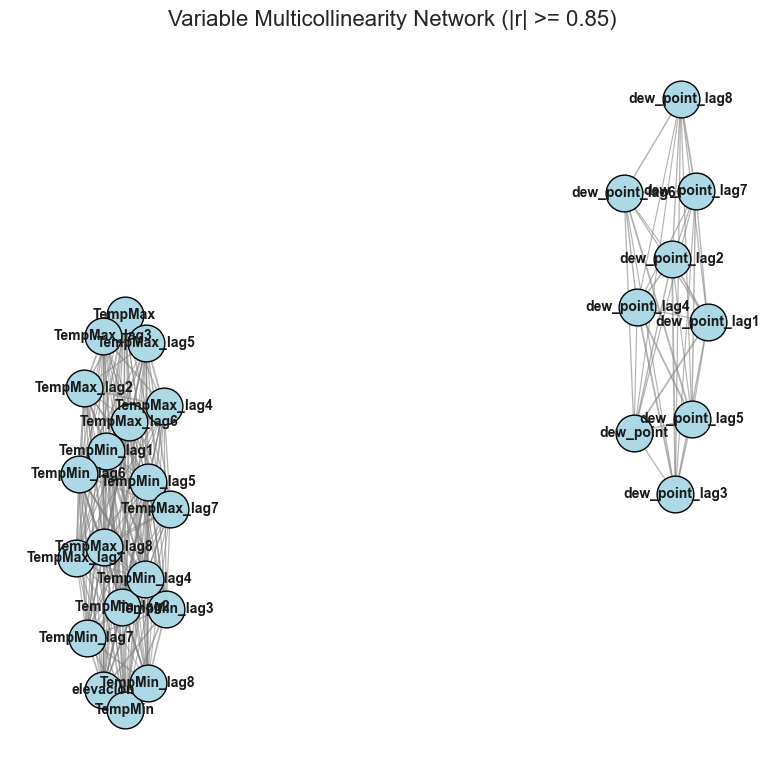

In [474]:
plot_collinearity_network(df.drop(columns='casosconfirmados'), threshold=0.85, figsize=(8, 8))

Como es de esperar, al haber introducido una cantidad importante de rezagos temporales para las variables: TempMax, TempMin, Precipitacion, ndvi, dew_point hay escenarios de altisima correlación, principalmente se hacen notorias las relaciones que hay entre los 2 niveles de temperaturas y la elevacion, pues es la red más extensa, además se nota la correlación que hay entre la humedad dew_point y sus rezagos.

Resulta agradable también que variables como el indice de vegetación y la humedad no tengna correalción demasiado alta con otras variables lo cual, en últimas es positivo para el modelo.

In [475]:
#* eliminacion de elevacion por alta correlacion con temperaturas y obtencion de variable de temperatura media para eliminar multicolinealidad
df = pd.read_csv(f'data/dengue_data_v4_{hoja_start}.csv', sep='|')
df.drop(columns='elevacion', inplace=True)
#* get vars of temperatura max y min y crear el valor medio entre ellas para eliminar multicolinealidad
temp_max_cols = [col for col in df.columns if 'TempMax' in col]
temp_min_cols = [col for col in df.columns if 'TempMin' in col]
for max_col, min_col in zip(temp_max_cols, temp_min_cols):
    mean_col_name = max_col.replace('TempMax', 'TempMean')
    df[mean_col_name] = (df[max_col] + df[min_col]) / 2
df.drop(columns=temp_max_cols + temp_min_cols, inplace=True)
df.head()

,year,mes,casosconfirmados,longitud,latitud,Precipitacion,Precipitacion_lag1,Precipitacion_lag2,Precipitacion_lag3,Precipitacion_lag4,Precipitacion_lag5,Precipitacion_lag6,Precipitacion_lag7,Precipitacion_lag8,fenomeno,fenomeno_lag1,fenomeno_lag2,fenomeno_lag3,fenomeno_lag4,fenomeno_lag5,fenomeno_lag6,fenomeno_lag7,fenomeno_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,dew_point_lag1,dew_point_lag2,dew_point_lag3,dew_point_lag4,dew_point_lag5,dew_point_lag6,dew_point_lag7,dew_point_lag8,TempMean,TempMean_lag1,TempMean_lag2,TempMean_lag3,TempMean_lag4,TempMean_lag5,TempMean_lag6,TempMean_lag7,TempMean_lag8
0,2007,1,16.0,-70.747408,7.072726,6.6,30.6,95.7,212.2,132.6,206.3,469.6,346.5,269.5,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,neutral,0.561986,291.948053,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,0.664694,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694,295.882281,28.0,28.0,28.0,28.0,27.5,27.0,26.5,26.5,26.5
1,2007,2,30.0,-70.747408,7.072726,11.2,6.6,30.6,95.7,212.2,132.6,206.3,469.6,346.5,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,neutral,0.442583,288.149941,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694,28.5,28.0,28.0,28.0,28.0,27.5,27.0,26.5,26.5
2,2007,3,58.0,-70.747408,7.072726,70.8,11.2,6.6,30.6,95.7,212.2,132.6,206.3,469.6,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,neutral,0.380690,291.867835,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,29.5,28.5,28.0,28.0,28.0,28.0,27.5,27.0,26.5
3,2007,4,41.0,-70.747408,7.072726,118.0,70.8,11.2,6.6,30.6,95.7,212.2,132.6,206.3,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,neutral,0.658117,296.449290,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,28.5,29.5,28.5,28.0,28.0,28.0,28.0,27.5,27.0
4,2007,5,83.0,-70.747408,7.072726,193.6,118.0,70.8,11.2,6.6,30.6,95.7,212.2,132.6,neutral,neutral,neutral,neutral,nino_mod,nino_mod,nino_mod,nino_mod,nino_mod,0.668407,296.416535,0.658117,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,296.449290,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,27.5,28.5,29.5,28.5,28.0,28.0,28.0,28.0,27.5


In [476]:
df = pd.get_dummies(df, columns=['mes'] + [i for i in df.columns if 'fenomeno' in i], drop_first=True, dtype=int)
df.head()

,year,casosconfirmados,longitud,latitud,Precipitacion,Precipitacion_lag1,Precipitacion_lag2,Precipitacion_lag3,Precipitacion_lag4,Precipitacion_lag5,Precipitacion_lag6,Precipitacion_lag7,Precipitacion_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,dew_point_lag1,dew_point_lag2,dew_point_lag3,dew_point_lag4,dew_point_lag5,dew_point_lag6,dew_point_lag7,dew_point_lag8,TempMean,TempMean_lag1,TempMean_lag2,TempMean_lag3,TempMean_lag4,TempMean_lag5,TempMean_lag6,TempMean_lag7,TempMean_lag8,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,fenomeno_nina_mod,fenomeno_nina_sev,fenomeno_nino_mod,fenomeno_nino_sev,fenomeno_lag1_nina_mod,fenomeno_lag1_nina_sev,fenomeno_lag1_nino_mod,fenomeno_lag1_nino_sev,fenomeno_lag2_nina_mod,fenomeno_lag2_nina_sev,fenomeno_lag2_nino_mod,fenomeno_lag2_nino_sev,fenomeno_lag3_nina_mod,fenomeno_lag3_nina_sev,fenomeno_lag3_nino_mod,fenomeno_lag3_nino_sev,fenomeno_lag4_nina_mod,fenomeno_lag4_nina_sev,fenomeno_lag4_nino_mod,fenomeno_lag4_nino_sev,fenomeno_lag5_nina_mod,fenomeno_lag5_nina_sev,fenomeno_lag5_nino_mod,fenomeno_lag5_nino_sev,fenomeno_lag6_nina_mod,fenomeno_lag6_nina_sev,fenomeno_lag6_nino_mod,fenomeno_lag6_nino_sev,fenomeno_lag7_nina_mod,fenomeno_lag7_nina_sev,fenomeno_lag7_nino_mod,fenomeno_lag7_nino_sev,fenomeno_lag8_nina_mod,fenomeno_lag8_nina_sev,fenomeno_lag8_nino_mod,fenomeno_lag8_nino_sev
0,2007,16.0,-70.747408,7.072726,6.6,30.6,95.7,212.2,132.6,206.3,469.6,346.5,269.5,0.561986,291.948053,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,0.664694,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694,295.882281,28.0,28.0,28.0,28.0,27.5,27.0,26.5,26.5,26.5,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2007,30.0,-70.747408,7.072726,11.2,6.6,30.6,95.7,212.2,132.6,206.3,469.6,346.5,0.442583,288.149941,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694,28.5,28.0,28.0,28.0,28.0,27.5,27.0,26.5,26.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2007,58.0,-70.747408,7.072726,70.8,11.2,6.6,30.6,95.7,212.2,132.6,206.3,469.6,0.380690,291.867835,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,29.5,28.5,28.0,28.0,28.0,28.0,27.5,27.0,26.5,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
3,2007,41.0,-70.747408,7.072726,118.0,70.8,11.2,6.6,30.6,95.7,212.2,132.6,206.3,0.658117,296.449290,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,28.5,29.5,28.5,28.0,28.0,28.0,28.0,27.5,27.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0
4,2007,83.0,-70.747408,7.072726,193.6,118.0,70.8,11.2,6.6,30.6,95.7,212.2,132.6,0.668407,296.416535,0.658117,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,296.449290,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,27.5,28.5,29.5,28.5,28.0,28.0,28.0,28.0,27.5,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0


In [477]:
danger_pairs = get_high_correlation_pairs(df.drop(columns='casosconfirmados'), threshold=0.85)
danger_pairs

,Feature_1,Feature_2,Correlation
0,TempMean_lag8,TempMean_lag7,0.990453
1,TempMean_lag7,TempMean_lag6,0.990335
2,TempMean_lag5,TempMean_lag4,0.990284
3,TempMean_lag6,TempMean_lag5,0.990279
4,TempMean_lag4,TempMean_lag3,0.990262
...,...,...,...
67,dew_point_lag5,dew_point_lag1,0.932976
68,dew_point_lag6,dew_point_lag2,0.932856
69,dew_point_lag7,dew_point_lag3,0.932841
70,dew_point_lag8,dew_point_lag4,0.932732


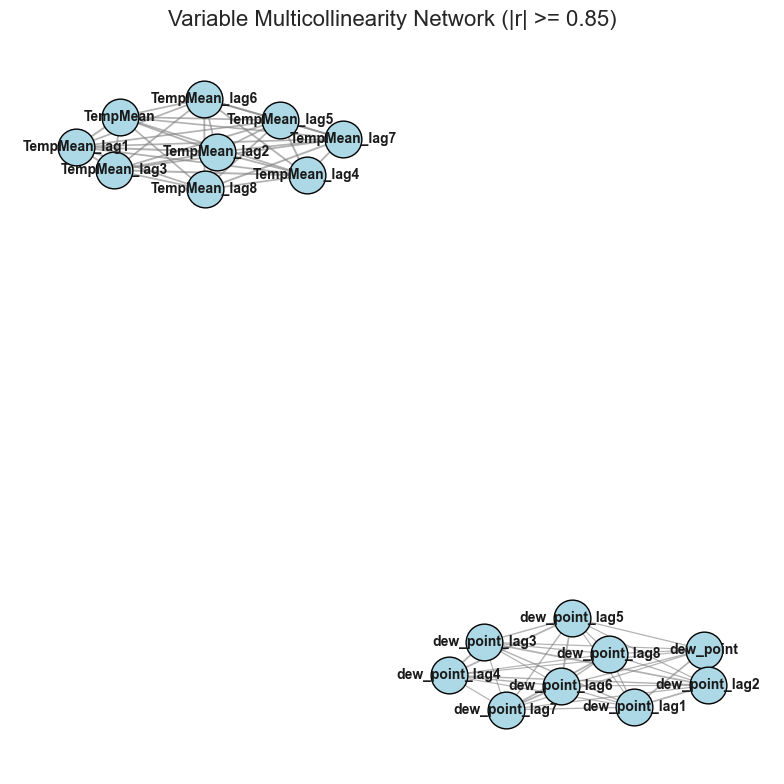

In [478]:
plot_collinearity_network(df.drop(columns='casosconfirmados'), threshold=0.85, figsize=(8, 8))

Tras la eliminación de la elevación y el suavizado de las temperaturas las altas correlaciones se concentran en la nueva metrica de temperatura y sus rezagos, y para la humedad también se presenta alta correlación entre los rezagos.

Para responder a esto, debemos empezar por justificar el uso de herramientas apropiadas para extraer los más importante de los datos obtenidos, por ello retomamos parte de la fundamentación del proyecto, donde los ciclos de vida del mosquito aedes se extienden bajo condiciones climaticas especificas por hasta 8 meses (puede darse un estado de suspensión en el desarrollo normal del mosquito). Es por esto que existe la presunción de que los datos climaticos importan en muy buena parte, así se va a utilizar el análisis de componentes principales (PCA) para extraer la trayectoria completa de los datos en el menor numero de variables.

In [479]:
df

,year,casosconfirmados,longitud,latitud,Precipitacion,Precipitacion_lag1,Precipitacion_lag2,Precipitacion_lag3,Precipitacion_lag4,Precipitacion_lag5,Precipitacion_lag6,Precipitacion_lag7,Precipitacion_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,dew_point_lag1,dew_point_lag2,dew_point_lag3,dew_point_lag4,dew_point_lag5,dew_point_lag6,dew_point_lag7,dew_point_lag8,TempMean,TempMean_lag1,TempMean_lag2,TempMean_lag3,TempMean_lag4,TempMean_lag5,TempMean_lag6,TempMean_lag7,TempMean_lag8,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,fenomeno_nina_mod,fenomeno_nina_sev,fenomeno_nino_mod,fenomeno_nino_sev,fenomeno_lag1_nina_mod,fenomeno_lag1_nina_sev,fenomeno_lag1_nino_mod,fenomeno_lag1_nino_sev,fenomeno_lag2_nina_mod,fenomeno_lag2_nina_sev,fenomeno_lag2_nino_mod,fenomeno_lag2_nino_sev,fenomeno_lag3_nina_mod,fenomeno_lag3_nina_sev,fenomeno_lag3_nino_mod,fenomeno_lag3_nino_sev,fenomeno_lag4_nina_mod,fenomeno_lag4_nina_sev,fenomeno_lag4_nino_mod,fenomeno_lag4_nino_sev,fenomeno_lag5_nina_mod,fenomeno_lag5_nina_sev,fenomeno_lag5_nino_mod,fenomeno_lag5_nino_sev,fenomeno_lag6_nina_mod,fenomeno_lag6_nina_sev,fenomeno_lag6_nino_mod,fenomeno_lag6_nino_sev,fenomeno_lag7_nina_mod,fenomeno_lag7_nina_sev,fenomeno_lag7_nino_mod,fenomeno_lag7_nino_sev,fenomeno_lag8_nina_mod,fenomeno_lag8_nina_sev,fenomeno_lag8_nino_mod,fenomeno_lag8_nino_sev
0,2007,16.0,-70.747408,7.072726,6.6,30.6,95.7,212.2,132.6,206.3,469.6,346.5,269.5,0.561986,291.948053,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,0.664694,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694,295.882281,28.0,28.0,28.0,28.0,27.5,27.0,26.5,26.5,26.5,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2007,30.0,-70.747408,7.072726,11.2,6.6,30.6,95.7,212.2,132.6,206.3,469.6,346.5,0.442583,288.149941,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,295.938694,28.5,28.0,28.0,28.0,28.0,27.5,27.0,26.5,26.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2007,58.0,-70.747408,7.072726,70.8,11.2,6.6,30.6,95.7,212.2,132.6,206.3,469.6,0.380690,291.867835,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,295.639213,29.5,28.5,28.0,28.0,28.0,28.0,27.5,27.0,26.5,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
3,2007,41.0,-70.747408,7.072726,118.0,70.8,11.2,6.6,30.6,95.7,212.2,132.6,206.3,0.658117,296.449290,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,296.121799,28.5,29.5,28.5,28.0,28.0,28.0,28.0,27.5,27.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0
4,2007,83.0,-70.747408,7.072726,193.6,118.0,70.8,11.2,6.6,30.6,95.7,212.2,132.6,0.668407,296.416535,0.658117,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,296.449290,291.867835,288.149941,291.948053,294.805262,296.108437,296.727496,296.357899,27.5,28.5,29.5,28.5,28.0,28.0,28.0,28.0,27.5,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105439,2024,1.0,-70.859499,5.136393,255.6,325.7,431.9,340.8,231.1,70.7,31.3,15.9,37.8,0.664978,295.258564,0.511568,0.584245,0.684736,0.601316,0.590652,0.590001,0.634855,0.660294,295.258564,295.258564,295.258564,295.258564,295.25856

In [480]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def compress_lags_with_pca(df: pd.DataFrame, feature_prefix: str, lags: int = 8) -> pd.DataFrame:
    """
    Takes a dataframe, identifies the lag columns for a specific feature, 
    standardizes them, applies PCA to extract the 1st Principal Component, 
    adds it to the dataframe, and drops the original lags.
    """
    # 1. Identify the specific lag columns
    lag_cols = [f'{feature_prefix}_lag{i}' for i in range(1, lags + 1)]
    
    # 2. Check if columns exist to avoid errors
    missing_cols = [col for col in lag_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing expected columns in dataframe: {missing_cols}")

    # 3. Create a mask to isolate rows with NO missing lag data
    # (PCA cannot process NaNs, which naturally occur in the first few months of a time series)
    valid_mask = df[lag_cols].notna().all(axis=1)
    
    if not valid_mask.any():
        print(f"Warning: No valid complete rows found for {feature_prefix}.")
        return df
        
    # Extract the clean subset of data
    X_lags = df.loc[valid_mask, lag_cols]
    
    # 4. Standardize the data (Critical for accurate PCA)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_lags)
    
    # 5. Initialize and fit PCA to capture the primary variance
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(X_scaled)
    
    # Print a diagnostic so you know how much information you retained
    explained_var = pca.explained_variance_ratio_[0] * 100
    print(f"✅ {feature_prefix}: PC1 captured {explained_var:.2f}% of the variance across {lags} months.")
    
    # 6. Add the new Principal Component back to the original dataframe
    # We use .loc to ensure the PC1 values snap back onto the correct chronological rows
    new_col_name = f'{feature_prefix}_History_PC1'
    df.loc[valid_mask, new_col_name] = pc1[:, 0]
    
    # 7. Drop the original highly correlated lag columns to clean up the dataset
    df.drop(columns=lag_cols, inplace=True)
    
    return df

# ==========================================
# How to apply it to your dataset
# ==========================================

# Assuming 'df' is your final dataframe from the worldclim function
# Compress Mean Temperature lags
df = compress_lags_with_pca(df, feature_prefix='TempMean', lags=8)

# Compress Dew Point lags
df = compress_lags_with_pca(df, feature_prefix='dew_point', lags=8)

# Now, instead of 16 highly correlated lag columns, you have 2 clean, independent indices:
# 'TempMean_History_PC1' and 'DewPoint_History_PC1'

✅ TempMean: PC1 captured 98.38% of the variance across 8 months.
✅ dew_point: PC1 captured 95.66% of the variance across 8 months.


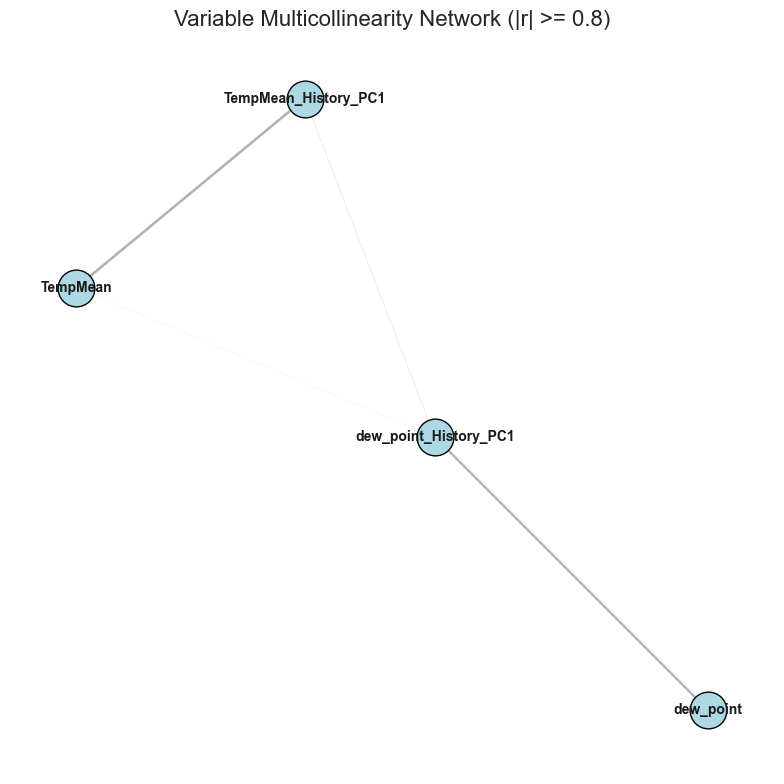

In [481]:
plot_collinearity_network(df.drop(columns='casosconfirmados'), threshold=0.8, figsize=(8, 8))

In [482]:
print("Variables finales para modelado:")
print(df.columns.tolist())
print("departamentos incluidos:", depts_10)

Variables finales para modelado:
['year', 'casosconfirmados', 'longitud', 'latitud', 'Precipitacion', 'Precipitacion_lag1', 'Precipitacion_lag2', 'Precipitacion_lag3', 'Precipitacion_lag4', 'Precipitacion_lag5', 'Precipitacion_lag6', 'Precipitacion_lag7', 'Precipitacion_lag8', 'ndvi', 'dew_point', 'ndvi_lag1', 'ndvi_lag2', 'ndvi_lag3', 'ndvi_lag4', 'ndvi_lag5', 'ndvi_lag6', 'ndvi_lag7', 'ndvi_lag8', 'TempMean', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12', 'fenomeno_nina_mod', 'fenomeno_nina_sev', 'fenomeno_nino_mod', 'fenomeno_nino_sev', 'fenomeno_lag1_nina_mod', 'fenomeno_lag1_nina_sev', 'fenomeno_lag1_nino_mod', 'fenomeno_lag1_nino_sev', 'fenomeno_lag2_nina_mod', 'fenomeno_lag2_nina_sev', 'fenomeno_lag2_nino_mod', 'fenomeno_lag2_nino_sev', 'fenomeno_lag3_nina_mod', 'fenomeno_lag3_nina_sev', 'fenomeno_lag3_nino_mod', 'fenomeno_lag3_nino_sev', 'fenomeno_lag4_nina_mod', 'fenomeno_lag4_nina_sev', 'fenomeno_lag4_nino_mod', 'fenomeno

In [483]:
#* eliminacion de casos confirmados no imputables perdida de al rededor de 3000 casosconfirmados
df.dropna(subset='casosconfirmados',inplace=True)



df.to_csv(f'data/dengue_data_vfnl_{hoja_start}.csv', index=False, sep='|')
df.info()


<class 'pandas.DataFrame'>
Index: 102336 entries, 0 to 105443
Data columns (total 73 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   year                    102336 non-null  int64  
 1   casosconfirmados        102336 non-null  float64
 2   longitud                102336 non-null  float64
 3   latitud                 102336 non-null  float64
 4   Precipitacion           102336 non-null  float64
 5   Precipitacion_lag1      102336 non-null  float64
 6   Precipitacion_lag2      102336 non-null  float64
 7   Precipitacion_lag3      102336 non-null  float64
 8   Precipitacion_lag4      102336 non-null  float64
 9   Precipitacion_lag5      102336 non-null  float64
 10  Precipitacion_lag6      102336 non-null  float64
 11  Precipitacion_lag7      102336 non-null  float64
 12  Precipitacion_lag8      102336 non-null  float64
 13  ndvi                    102336 non-null  float64
 14  dew_point               102336 non-n

In [467]:

df

,year,casosconfirmados,longitud,latitud,Precipitacion,Precipitacion_lag1,Precipitacion_lag2,Precipitacion_lag3,Precipitacion_lag4,Precipitacion_lag5,Precipitacion_lag6,Precipitacion_lag7,Precipitacion_lag8,ndvi,dew_point,ndvi_lag1,ndvi_lag2,ndvi_lag3,ndvi_lag4,ndvi_lag5,ndvi_lag6,ndvi_lag7,ndvi_lag8,TempMean,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,fenomeno_nina_mod,fenomeno_nina_sev,fenomeno_nino_mod,fenomeno_nino_sev,fenomeno_lag1_nina_mod,fenomeno_lag1_nina_sev,fenomeno_lag1_nino_mod,fenomeno_lag1_nino_sev,fenomeno_lag2_nina_mod,fenomeno_lag2_nina_sev,fenomeno_lag2_nino_mod,fenomeno_lag2_nino_sev,fenomeno_lag3_nina_mod,fenomeno_lag3_nina_sev,fenomeno_lag3_nino_mod,fenomeno_lag3_nino_sev,fenomeno_lag4_nina_mod,fenomeno_lag4_nina_sev,fenomeno_lag4_nino_mod,fenomeno_lag4_nino_sev,fenomeno_lag5_nina_mod,fenomeno_lag5_nina_sev,fenomeno_lag5_nino_mod,fenomeno_lag5_nino_sev,fenomeno_lag6_nina_mod,fenomeno_lag6_nina_sev,fenomeno_lag6_nino_mod,fenomeno_lag6_nino_sev,fenomeno_lag7_nina_mod,fenomeno_lag7_nina_sev,fenomeno_lag7_nino_mod,fenomeno_lag7_nino_sev,fenomeno_lag8_nina_mod,fenomeno_lag8_nina_sev,fenomeno_lag8_nino_mod,fenomeno_lag8_nino_sev,TempMean_History_PC1,dew_point_History_PC1
0,2007,16.0,-70.747408,7.072726,6.6,30.6,95.7,212.2,132.6,206.3,469.6,346.5,269.5,0.561986,291.948053,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,0.664694,28.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.903664,2.877353
1,2007,30.0,-70.747408,7.072726,11.2,6.6,30.6,95.7,212.2,132.6,206.3,469.6,346.5,0.442583,288.149941,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,0.631398,28.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2.028116,2.560551
2,2007,58.0,-70.747408,7.072726,70.8,11.2,6.6,30.6,95.7,212.2,132.6,206.3,469.6,0.380690,291.867835,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,0.615328,29.5,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,2.193802,1.932706
3,2007,41.0,-70.747408,7.072726,118.0,70.8,11.2,6.6,30.6,95.7,212.2,132.6,206.3,0.658117,296.449290,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,0.619094,28.5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,2.442032,1.625826
4,2007,83.0,-70.747408,7.072726,193.6,118.0,70.8,11.2,6.6,30.6,95.7,212.2,132.6,0.668407,296.416535,0.658117,0.380690,0.442583,0.561986,0.657413,0.675929,0.651289,0.640121,27.5,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,2.566405,1.649991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105439,2024,1.0,-70.859499,5.136393,255.6,325.7,431.9,340.8,231.1,70.7,31.3,15.9,37.8,0.664978,295.258564,0.511568,0.584245,0.684736,0.601316,0.590652,0.590001,0.634855,0.660294,26.5,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,2.277318,2.432168
105440,2024,3.0,-70.859499,5.136393,211.5,255.6,325.7,431.9,340.8,231.1,70.7,31.3,15.9,0.679174,295.258564,0.664978,0.511568,0.584245,0.684736,0.601316,0.590652,0.590001,0.634855,27.5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,2.193760,2.432168
105441,2024,2.0,-70.859499,5.136393,238.2,211.5,255.6,325.7,431.9,340.8,231.1,70.7,31.3,0.654291,295.258564,0.679174,0.664978,0.511568,0.584245,0.684736,0.601316,0.590652,0.590001,27.5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,2.110060,2.432168
105442,2024,0.0,-70.859499,5.136393,149.6,238.2,211.5,255.6,325.7,431.9,340.8,231.1,70.7,0.679315,295.258564,0.654291,0.679174,0.664978,0.